# 🎯 **Support Vector Machine (SVM)**

## **Yönetim Bilişim Sistemleri için Kapsamlı SVM Rehberi**

# 📊 **Adım 1: SVM'e Neden İhtiyaç Duyuyoruz?**

## 🏢 **Çalışan Terfi Tahmin Problemi: Gerçek Bir İK Senaryosu**

Bir **şirketin İnsan Kaynakları departmanında** çalıştığınızı hayal edin. Yıl sonu performans değerlendirmesi yaklaşıyor ve yönetim ekibi sizden kritik bir analiz bekliyor:

> **"Hangi çalışanlar terfiye layıktır? Kimleri terfi ettirmeliyiz?"**

### 🎯 **Problem Tanımı**

Bu bir **ikili sınıflandırma** problemidir:
- **Sınıf 1 (Terfi)**: Çalışan terfiye layık ✅
- **Sınıf 0 (Terfi Yok)**: Çalışan henüz hazır değil ❌

### 📋 **Çalışan Özellikleri (Features)**

Her çalışan için elimizde **12 farklı değişken** var:

1. 📅 **Çalışma Süresi**: Şirkette kaç yıldır çalışıyor
2. 🎂 **Yaş**: Çalışanın yaşı
3. 📊 **Performans Puanı**: 0-100 arası performans skoru
4. 🎓 **Eğitim Seviyesi**: 1(Lise) - 5(Doktora)
5. 📁 **Proje Sayısı**: Son 1 yılda tamamlanan proje sayısı
6. ⏰ **Fazla Mesai**: Aylık ortalama fazla mesai saati
7. 📚 **Eğitim Katılımı**: Yıllık katıldığı eğitim sayısı
8. 👥 **Takım Skoru**: Takım içi işbirliği puanı (0-100)
9. 😊 **Müşteri Memnuniyeti**: Müşteri geri bildirim puanı (0-100)
10. 🏥 **Devamsızlık**: Yıllık izinsiz devamsızlık günü
11. 💰 **Maaş**: Mevcut maaş (TL)
12. 🎯 **Terfi Durumu**: 0 (Terfi Yok) veya 1 (Terfi)

### ❓ **Peki Sorun Ne?**

Daha önce **Lineer Regresyon** ve **Lojistik Regresyon** öğrendik. Onlarda da bir **karar çizgisi** çiziyorduk:
- Çizginin **bir tarafı** → Terfi edilecek
- Çizginin **diğer tarafı** → Terfi edilmeyecek

**Ancak kritik soru şu:** Bu çizgiyi **nereye** çizeceğiz?

- Çizgiyi biraz **sağa** kaydırsak → 12 çalışan yanlış değerlendiriliyor
- Çizgiyi biraz **sola** kaydırsak → 18 çalışan yanlış değerlendiriliyor

**Hatalı terfi kararlarının maliyeti yüksektir:**
- ❌ Hak etmeyen birine terfi → Takım morali bozulur
- ❌ Hak edeni terfi ettirmemek → Değerli çalışan şirketten ayrılır

### 💡 **SVM'in Çözümü**

**Support Vector Machine** sadece bir çizgi çizmez! Bunun yerine:

1. **En güvenli mesafeli** karar sınırını çizer
2. İki grup arasında **mümkün olan en geniş boşluk** (marjin) bırakır
3. **Geniş boşluk** = **Güvenli ve adil karar**

Bu yüzden SVM'e **"Marjini maksimize eden algoritma"** denir.

**İK perspektifinden:** SVM, terfi kararlarında hem adaleti sağlar hem de belirsizliği azaltır.

In [3]:
# Gerekli kütüphaneleri içe aktarıyoruz
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

# Grafik ayarları - daha profesyonel görünüm için
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("✅ Kütüphaneler başarıyla yüklendi!")
print("📚 Kullanılan ana kütüphaneler: NumPy, Pandas, Matplotlib, Scikit-learn")

✅ Kütüphaneler başarıyla yüklendi!
📚 Kullanılan ana kütüphaneler: NumPy, Pandas, Matplotlib, Scikit-learn


## 💼 **Çalışan Terfi Veri Seti Oluşturma**

Şimdi **gerçekçi bir şirket senaryosu** için 4,723 çalışandan oluşan 12 sütunlu veri seti oluşturalım:

In [6]:
# Tekrarlanabilirlik için seed ayarlıyoruz
np.random.seed(42)

# Toplam çalışan sayısı
n_samples = 4723

# Terfi edilecek çalışan oranı (%32 - gerçekçi bir oran)
n_terfi = int(n_samples * 0.32)
n_terfi_yok = n_samples - n_terfi

print("🏢 Sentetik Çalışan Veri Seti Oluşturuluyor...")
print("="*70)

# TERFİ EDİLECEK çalışanlar (Sınıf 1) - Yüksek performans özellikleri
terfi_calisma_suresi = np.random.normal(7, 2, n_terfi).clip(2, 25)  # 2-25 yıl arası
terfi_yas = np.random.normal(38, 6, n_terfi).clip(25, 60)  # 25-60 yaş arası
terfi_performans = np.random.normal(82, 8, n_terfi).clip(60, 100)  # Yüksek performans
terfi_egitim = np.random.choice([3, 4, 5], n_terfi, p=[0.3, 0.5, 0.2])  # Lisans ve üstü
terfi_proje = np.random.normal(8, 2, n_terfi).clip(4, 15).astype(int)  # Çok proje
terfi_mesai = np.random.normal(35, 10, n_terfi).clip(15, 80)  # Fazla mesai
terfi_egitim_katilim = np.random.normal(6, 2, n_terfi).clip(3, 12).astype(int)  # Eğitimlere katılım
terfi_takim = np.random.normal(85, 7, n_terfi).clip(65, 100)  # Yüksek takım skoru
terfi_musteri = np.random.normal(87, 6, n_terfi).clip(70, 100)  # Yüksek müşteri memnuniyeti
terfi_devamsizlik = np.random.normal(2, 1.5, n_terfi).clip(0, 8).astype(int)  # Az devamsızlık
terfi_maas = np.random.normal(18000, 4000, n_terfi).clip(10000, 35000)  # Yüksek maaş

# TERFİ EDİLMEYECEK çalışanlar (Sınıf 0) - Düşük performans özellikleri
noterfi_calisma_suresi = np.random.normal(3, 1.5, n_terfi_yok).clip(0.5, 15)  # Daha az tecrübe
noterfi_yas = np.random.normal(30, 7, n_terfi_yok).clip(22, 55)  # Genç veya deneyimsiz
noterfi_performans = np.random.normal(58, 12, n_terfi_yok).clip(20, 75)  # Düşük performans
noterfi_egitim = np.random.choice([1, 2, 3], n_terfi_yok, p=[0.2, 0.4, 0.4])  # Lise, önlisans, lisans
noterfi_proje = np.random.normal(4, 2, n_terfi_yok).clip(0, 8).astype(int)  # Az proje
noterfi_mesai = np.random.normal(12, 8, n_terfi_yok).clip(0, 40)  # Az mesai
noterfi_egitim_katilim = np.random.normal(2, 1.5, n_terfi_yok).clip(0, 6).astype(int)  # Az eğitim
noterfi_takim = np.random.normal(62, 12, n_terfi_yok).clip(30, 80)  # Düşük takım skoru
noterfi_musteri = np.random.normal(58, 15, n_terfi_yok).clip(25, 80)  # Düşük müşteri memnuniyeti
noterfi_devamsizlik = np.random.normal(6, 3, n_terfi_yok).clip(1, 25).astype(int)  # Fazla devamsızlık
noterfi_maas = np.random.normal(12000, 3000, n_terfi_yok).clip(5500, 22000)  # Düşük maaş

# Veri setini birleştiriyoruz
df = pd.DataFrame({
    'Calisma_Suresi': np.concatenate([terfi_calisma_suresi, noterfi_calisma_suresi]),
    'Yas': np.concatenate([terfi_yas, noterfi_yas]),
    'Performans_Puani': np.concatenate([terfi_performans, noterfi_performans]),
    'Egitim_Seviyesi': np.concatenate([terfi_egitim, noterfi_egitim]),
    'Proje_Sayisi': np.concatenate([terfi_proje, noterfi_proje]),
    'Fazla_Mesai_Saati': np.concatenate([terfi_mesai, noterfi_mesai]),
    'Egitim_Katilim': np.concatenate([terfi_egitim_katilim, noterfi_egitim_katilim]),
    'Takim_Skoru': np.concatenate([terfi_takim, noterfi_takim]),
    'Musteri_Memnuniyeti': np.concatenate([terfi_musteri, noterfi_musteri]),
    'Devamsizlik_Gunu': np.concatenate([terfi_devamsizlik, noterfi_devamsizlik]),
    'Maas': np.concatenate([terfi_maas, noterfi_maas]),
    'Terfi_Durumu': np.concatenate([np.ones(n_terfi), np.zeros(n_terfi_yok)])
})

# Verileri karıştırıyoruz (shuffle)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Tamsayı olması gereken sütunları düzeltiyoruz
df['Calisma_Suresi'] = df['Calisma_Suresi'].round(1)
df['Yas'] = df['Yas'].astype(int)
df['Performans_Puani'] = df['Performans_Puani'].round(1)
df['Fazla_Mesai_Saati'] = df['Fazla_Mesai_Saati'].round(0).astype(int)
df['Takim_Skoru'] = df['Takim_Skoru'].round(1)
df['Musteri_Memnuniyeti'] = df['Musteri_Memnuniyeti'].round(1)
df['Maas'] = df['Maas'].round(0).astype(int)
df['Terfi_Durumu'] = df['Terfi_Durumu'].astype(int)

# Eğitim seviyesi mapping'i
egitim_mapping = {1: 'Lise', 2: 'Önlisans', 3: 'Lisans', 4: 'Yüksek Lisans', 5: 'Doktora'}
df['Egitim_Seviyesi_Text'] = df['Egitim_Seviyesi'].map(egitim_mapping)

print("✅ Veri seti başarıyla oluşturuldu!")
print("="*70)
print(f"📊 Toplam Çalışan Sayısı: {len(df):,}")
print(f"✅ Terfi Edilecek: {df['Terfi_Durumu'].sum():,} kişi ({df['Terfi_Durumu'].sum()/len(df)*100:.1f}%)")
print(f"❌ Terfi Edilmeyecek: {(df['Terfi_Durumu']==0).sum():,} kişi ({(df['Terfi_Durumu']==0).sum()/len(df)*100:.1f}%)")
print(f"📋 Toplam Özellik Sayısı: {len(df.columns)} sütun")
print("\n📋 İlk 8 çalışan:")
print(df[['Calisma_Suresi', 'Yas', 'Performans_Puani', 'Egitim_Seviyesi_Text', 
         'Proje_Sayisi', 'Takim_Skoru', 'Maas', 'Terfi_Durumu']].head(8).to_string(index=False))
print("\n📊 Veri Seti Genel Özeti:")
print(df.groupby('Terfi_Durumu')[['Performans_Puani', 'Proje_Sayisi', 'Maas']].mean().round(2))

🏢 Sentetik Çalışan Veri Seti Oluşturuluyor...
✅ Veri seti başarıyla oluşturuldu!
📊 Toplam Çalışan Sayısı: 4,723
✅ Terfi Edilecek: 1,511 kişi (32.0%)
❌ Terfi Edilmeyecek: 3,212 kişi (68.0%)
📋 Toplam Özellik Sayısı: 13 sütun

📋 İlk 8 çalışan:
 Calisma_Suresi  Yas  Performans_Puani Egitim_Seviyesi_Text  Proje_Sayisi  Takim_Skoru  Maas  Terfi_Durumu
            1.4   26              60.5             Önlisans             4         66.2 11129             0
            1.4   29              56.6               Lisans             6         55.7 12185             0
            9.6   55              72.8              Doktora             8         87.7 21002             1
            1.4   25              67.4               Lisans             0         54.5  6092             0
            2.5   32              60.6             Önlisans             1         74.6  9866             0
            2.0   27              46.2             Önlisans             0         77.7 13822             0
          

## 📈 **Veri Setinin Detaylı Analizi ve Görselleştirilmesi**

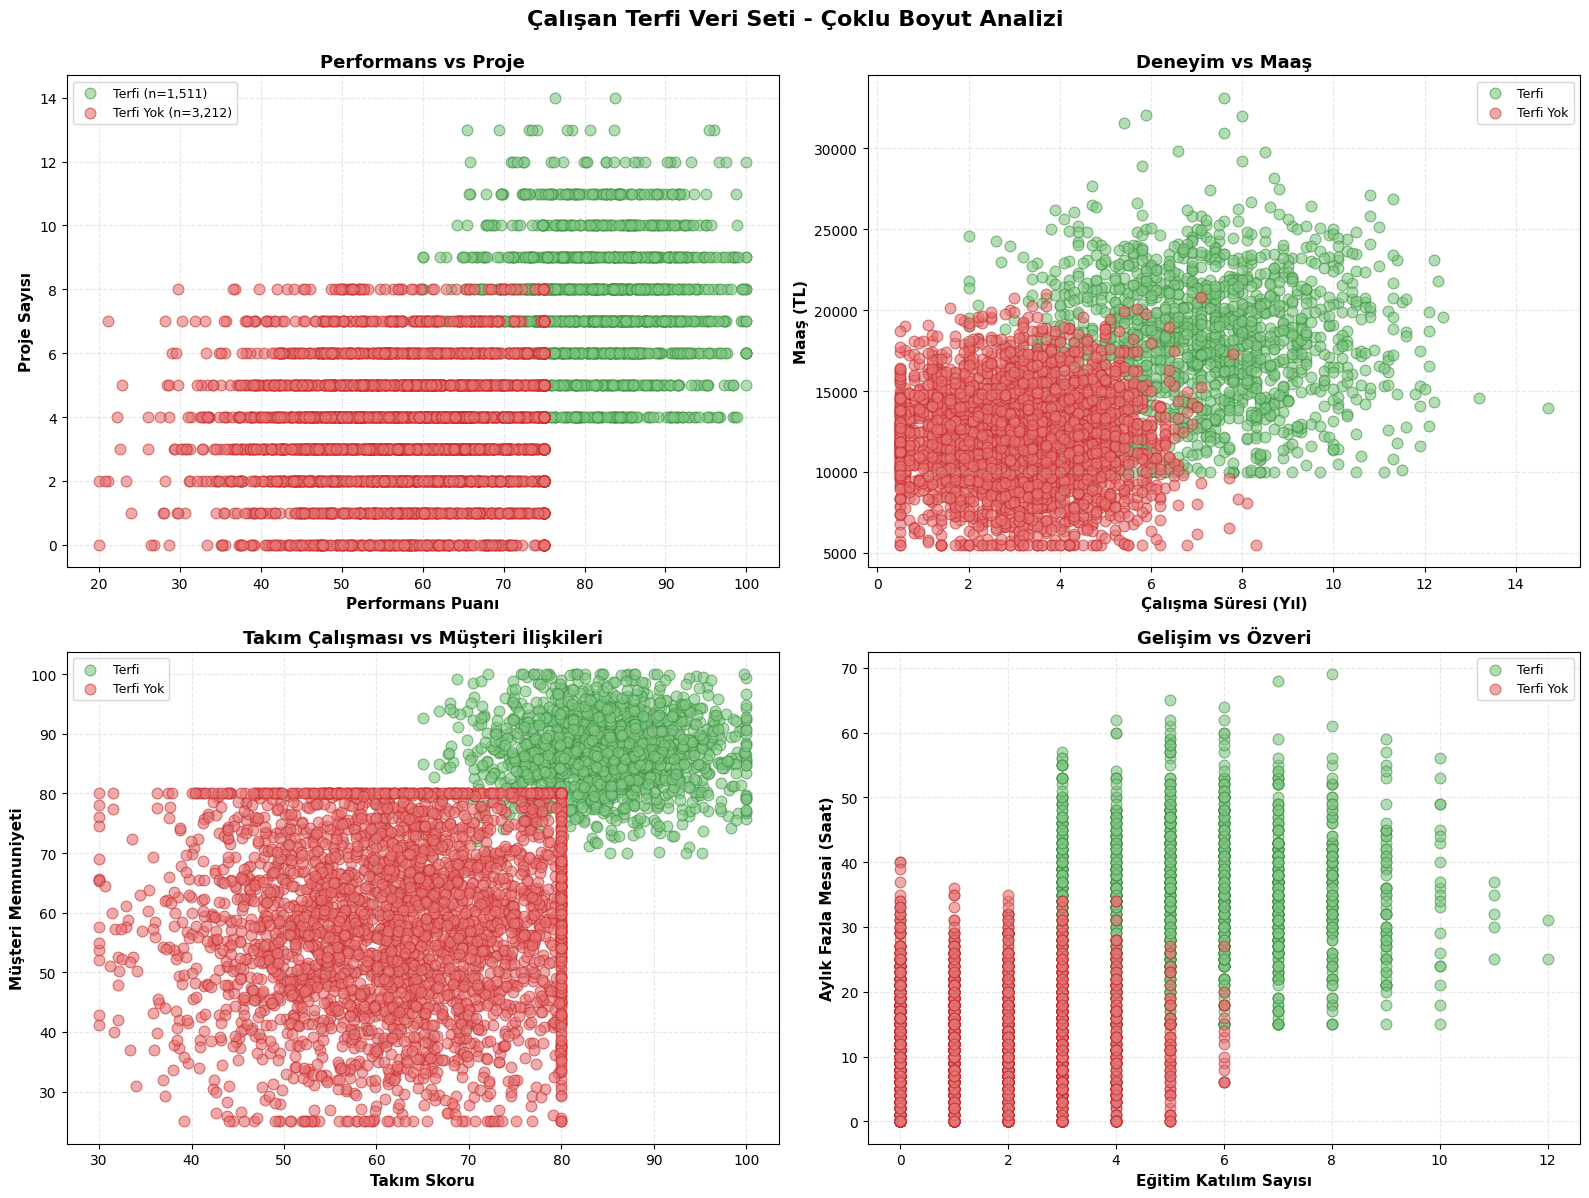


✅ Grafik Yorumları:
🟢 YEŞİL NOKTALAR (Terfi Edilenler):
   • Yüksek performans puanı ve fazla proje sayısı
   • Uzun çalışma süresi ve yüksek maaş
   • Yüksek takım skoru ve müşteri memnuniyeti
   • Düzenli eğitime katılım

🔴 KIRMIZI NOKTALAR (Terfi Edilmeyenler):
   • Düşük performans ve az proje
   • Kısa çalışma süresi veya düşük maaş
   • Düşük işbirliği ve müşteri skorları
   • Az eğitim katılımı

🎯 SONUÇ:
   İki grup arasında belirgin farklar var ancak bazı örtüşmeler mevcut.
   SVM, bu çok boyutlu uzayda EN GÜVENLI karar sınırını bulacak!


In [7]:
# 2D Scatter plot ile çalışanları görselleştiriyoruz
# En önemli 2 özelliği seçiyoruz: Performans Puanı ve Proje Sayısı

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Grafik: Performans Puanı vs Proje Sayısı
ax1 = axes[0, 0]
terfi_mask = df['Terfi_Durumu'] == 1
ax1.scatter(df[terfi_mask]['Performans_Puani'], df[terfi_mask]['Proje_Sayisi'], 
           c='#81C784', s=60, alpha=0.6, 
           edgecolors='#388E3C', linewidth=0.8,
           label=f'Terfi (n={terfi_mask.sum():,})')
ax1.scatter(df[~terfi_mask]['Performans_Puani'], df[~terfi_mask]['Proje_Sayisi'], 
           c='#E57373', s=60, alpha=0.6,
           edgecolors='#C62828', linewidth=0.8,
           label=f'Terfi Yok (n={(~terfi_mask).sum():,})')
ax1.set_xlabel('Performans Puanı', fontsize=11, fontweight='bold')
ax1.set_ylabel('Proje Sayısı', fontsize=11, fontweight='bold')
ax1.set_title('Performans vs Proje', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')

# 2. Grafik: Çalışma Süresi vs Maaş
ax2 = axes[0, 1]
ax2.scatter(df[terfi_mask]['Calisma_Suresi'], df[terfi_mask]['Maas'], 
           c='#81C784', s=60, alpha=0.6, 
           edgecolors='#388E3C', linewidth=0.8,
           label='Terfi')
ax2.scatter(df[~terfi_mask]['Calisma_Suresi'], df[~terfi_mask]['Maas'], 
           c='#E57373', s=60, alpha=0.6,
           edgecolors='#C62828', linewidth=0.8,
           label='Terfi Yok')
ax2.set_xlabel('Çalışma Süresi (Yıl)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Maaş (TL)', fontsize=11, fontweight='bold')
ax2.set_title('Deneyim vs Maaş', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, linestyle='--')

# 3. Grafik: Takım Skoru vs Müşteri Memnuniyeti
ax3 = axes[1, 0]
ax3.scatter(df[terfi_mask]['Takim_Skoru'], df[terfi_mask]['Musteri_Memnuniyeti'], 
           c='#81C784', s=60, alpha=0.6, 
           edgecolors='#388E3C', linewidth=0.8,
           label='Terfi')
ax3.scatter(df[~terfi_mask]['Takim_Skoru'], df[~terfi_mask]['Musteri_Memnuniyeti'], 
           c='#E57373', s=60, alpha=0.6,
           edgecolors='#C62828', linewidth=0.8,
           label='Terfi Yok')
ax3.set_xlabel('Takım Skoru', fontsize=11, fontweight='bold')
ax3.set_ylabel('Müşteri Memnuniyeti', fontsize=11, fontweight='bold')
ax3.set_title('Takım Çalışması vs Müşteri İlişkileri', fontsize=13, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, linestyle='--')

# 4. Grafik: Eğitim Katılımı vs Fazla Mesai
ax4 = axes[1, 1]
ax4.scatter(df[terfi_mask]['Egitim_Katilim'], df[terfi_mask]['Fazla_Mesai_Saati'], 
           c='#81C784', s=60, alpha=0.6, 
           edgecolors='#388E3C', linewidth=0.8,
           label='Terfi')
ax4.scatter(df[~terfi_mask]['Egitim_Katilim'], df[~terfi_mask]['Fazla_Mesai_Saati'], 
           c='#E57373', s=60, alpha=0.6,
           edgecolors='#C62828', linewidth=0.8,
           label='Terfi Yok')
ax4.set_xlabel('Eğitim Katılım Sayısı', fontsize=11, fontweight='bold')
ax4.set_ylabel('Aylık Fazla Mesai (Saat)', fontsize=11, fontweight='bold')
ax4.set_title('Gelişim vs Özveri', fontsize=13, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, linestyle='--')

plt.suptitle('Çalışan Terfi Veri Seti - Çoklu Boyut Analizi', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n✅ Grafik Yorumları:")
print("="*70)
print("🟢 YEŞİL NOKTALAR (Terfi Edilenler):")
print("   • Yüksek performans puanı ve fazla proje sayısı")
print("   • Uzun çalışma süresi ve yüksek maaş")
print("   • Yüksek takım skoru ve müşteri memnuniyeti")
print("   • Düzenli eğitime katılım\n")
print("🔴 KIRMIZI NOKTALAR (Terfi Edilmeyenler):")
print("   • Düşük performans ve az proje")
print("   • Kısa çalışma süresi veya düşük maaş")
print("   • Düşük işbirliği ve müşteri skorları")
print("   • Az eğitim katılımı\n")
print("🎯 SONUÇ:")
print("   İki grup arasında belirgin farklar var ancak bazı örtüşmeler mevcut.")
print("   SVM, bu çok boyutlu uzayda EN GÜVENLI karar sınırını bulacak!")

# 🧮 **WᵀX + b = 0 Ne Demek?**

## **Terfi Karar Sınırının Matematiksel Temeli**

Şimdi **en önemli formüle** bakalım. Korkutucu görünebilir ama aslında çok basit!

### 📝 **Basit Versiyonu (2 Özellikle)**

İK sistemimiz basitleştirilmiş halde şunu yapıyor:

```
w₁ × Performans_Puanı + w₂ × Proje_Sayısı + b = 0
```

**Ama gerçekte 11 özelliğimiz var!** Yani tam formül:

```
w₁×Çalışma_Süresi + w₂×Yaş + w₃×Performans_Puanı + w₄×Eğitim_Seviyesi + 
w₅×Proje_Sayısı + w₆×Fazla_Mesai + w₇×Eğitim_Katılım + w₈×Takım_Skoru + 
w₉×Müşteri_Memnuniyeti + w₁₀×Devamsızlık + w₁₁×Maaş + b = 0
```

### 🔍 **Bu Formülde Neler Var?**

| Sembol | Anlamı | İK Karşılığı |
|--------|--------|--------------|
| **w₁, w₂, ..., w₁₁** | Her özelliğin ağırlığı | Performans ne kadar önemli? Tecrübe ne kadar önemli? |
| **b** | Sabit terim (bias) | Temel eşik değeri - minimum terfi standardı |
| **x₁, x₂, ..., x₁₁** | Çalışan özellikleri | Gerçek değerler |

### 💡 **Örnek Senaryo (Sadece 3 Özellikle Gösterelim)**

Diyelim ki modelimiz şu ağırlıkları buldu (basitleştirilmiş):
- w_performans = 0.05 (Performans çok önemli!)
- w_proje = 0.8 (Proje sayısı da önemli)
- w_devamsızlık = -2.5 (Devamsızlık negatif etki eder)
- b = -5

**Yeni bir çalışan değerlendiriliyor:**
- Performans Puanı = 75
- Proje Sayısı = 6
- Devamsızlık = 3 gün

**Hesaplama:**
```
Skor = 0.05 × 75 + 0.8 × 6 + (-2.5) × 3 + (-5)
     = 3.75 + 4.8 - 7.5 - 5
     = -4.0
```

- **Skor > 0** ise → **TERFİ** ✅
- **Skor < 0** ise → **TERFİ YOK** ❌
- **Skor = 0** ise → **Karar sınırı üzerinde** (sınırda durum)

**Bu örnekte skor -4.0 olduğu için çalışan terfi alamaz.**

## 🎯 **Peki WᵀX + b Neden Kullanılıyor?**

Bu **lineer cebir notasyonu**dur. 11 özelliği tek satırda yazmanın yolu:

### **Vektör Gösterimi:**

**X** (özellik vektörü - 11 boyutlu):
```
X = [Çalışma_Süresi, Yaş, Performans, Eğitim, Proje, Mesai, Eğitim_Kat, 
     Takım, Müşteri, Devamsızlık, Maaş]
```

**W** (ağırlık vektörü - 11 boyutlu):
```
W = [w₁, w₂, w₃, w₄, w₅, w₆, w₇, w₈, w₉, w₁₀, w₁₁]
```

**Wᵀ × X** (iç çarpım):
```
Wᵀ × X = w₁×x₁ + w₂×x₂ + ... + w₁₁×x₁₁
```

### 🌟 **Bu Notasyonun Avantajları:**

1. **Genelleştirilebilir**: 2 özellik veya 1000 özellik olsa da aynı formül!
2. **Kompakt**: Tek satırda ifade ediliyor
3. **Bilgisayar dostu**: GPU'lar matris işlemlerinde çok hızlı
4. **Ölçeklenebilir**: Milyonlarca çalışan olsa bile aynı mantık

### 📊 **Görsel Açıklama**

In [8]:
# Mermaid ile matematiksel formül akışı
mermaid_math = '''
```mermaid
graph TD
    A[Çalışan Verileri<br/>11 Özellik] --> B[Çalışma Süresi, Yaş, Performans<br/>Eğitim, Proje, Mesai, vb.]
    B --> C[Vektör X<br/>11 boyutlu]
    
    D[Model Ağırlıkları<br/>Her özellik için] --> E[w₁, w₂, ..., w₁₁<br/>b: Sabit terim]
    E --> F[Vektör W<br/>11 boyutlu]
    
    C --> G[WᵀX + b<br/>Terfi Skoru]
    F --> G
    
    G --> H{Skor > 0 ?}
    H -->|Evet| I[TERFİ EDILECEK]
    H -->|Hayır| J[TERFİ YOK]
    
    style A fill:#E1F5FE,stroke:#0277BD,stroke-width:2px,color:#000
    style D fill:#F3E5F5,stroke:#7B1FA2,stroke-width:2px,color:#000
    style G fill:#FFF9C4,stroke:#F57F17,stroke-width:3px,color:#000
    style I fill:#C8E6C9,stroke:#388E3C,stroke-width:2px,color:#000
    style J fill:#FFCDD2,stroke:#C62828,stroke-width:2px,color:#000
```
'''

display(Markdown(mermaid_math))


```mermaid
graph TD
    A[Çalışan Verileri<br/>11 Özellik] --> B[Çalışma Süresi, Yaş, Performans<br/>Eğitim, Proje, Mesai, vb.]
    B --> C[Vektör X<br/>11 boyutlu]

    D[Model Ağırlıkları<br/>Her özellik için] --> E[w₁, w₂, ..., w₁₁<br/>b: Sabit terim]
    E --> F[Vektör W<br/>11 boyutlu]

    C --> G[WᵀX + b<br/>Terfi Skoru]
    F --> G

    G --> H{Skor > 0 ?}
    H -->|Evet| I[TERFİ EDILECEK]
    H -->|Hayır| J[TERFİ YOK]

    style A fill:#E1F5FE,stroke:#0277BD,stroke-width:2px,color:#000
    style D fill:#F3E5F5,stroke:#7B1FA2,stroke-width:2px,color:#000
    style G fill:#FFF9C4,stroke:#F57F17,stroke-width:3px,color:#000
    style I fill:#C8E6C9,stroke:#388E3C,stroke-width:2px,color:#000
    style J fill:#FFCDD2,stroke:#C62828,stroke-width:2px,color:#000
```


## 💻 Python ile Pratik Uygulama

In [9]:
# SVM modelini eğitelim ve gerçek ağırlıkları bulalım
# Önce basit bir model olarak 2 özellik kullanalım: Performans Puanı ve Proje Sayısı

# 2D analiz için veri hazırlama
X_simple = df[['Performans_Puani', 'Proje_Sayisi']].values
y_simple = df['Terfi_Durumu'].values

# Veriyi standartlaştır (SVM için önemli!)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_simple)

# SVM modelini eğit
svm_model = SVC(kernel='linear', C=1.0, random_state=42)
svm_model.fit(X_scaled, y_simple)

# Model ağırlıklarını al
w1_scaled = svm_model.coef_[0][0]
w2_scaled = svm_model.coef_[0][1]
b_scaled = svm_model.intercept_[0]

# Orijinal ölçekte ağırlıkları yaklaşık hesapla
w1 = w1_scaled / scaler.scale_[0]
w2 = w2_scaled / scaler.scale_[1]
b_approx = b_scaled - (w1 * scaler.mean_[0] + w2 * scaler.mean_[1])

print("🤖 SVM MODELİ EĞİTİLDİ")
print("="*70)
print(f"Model Doğruluğu: {svm_model.score(X_scaled, y_simple)*100:.2f}%")
print(f"\nModel Parametreleri (Basitleştirilmiş 2 Özellik için):")
print(f"  w₁ (Performans ağırlığı): {w1:.4f}")
print(f"  w₂ (Proje ağırlığı): {w2:.4f}")
print(f"  b (Bias): {b_approx:.4f}")
print("="*70)

# Örnek çalışan verileri - gerçek veriden seçelim
ornek_calisanlar = df.sample(5, random_state=42)[['Performans_Puani', 'Proje_Sayisi', 'Terfi_Durumu']].copy()
ornek_calisanlar['İsim'] = ['Ahmet Yılmaz', 'Ayşe Kara', 'Mehmet Demir', 'Zeynep Aksoy', 'Can Özkan']
ornek_calisanlar = ornek_calisanlar[['İsim', 'Performans_Puani', 'Proje_Sayisi', 'Terfi_Durumu']]

print("\n🏢 TERFİ DEĞERLENDİRME SİSTEMİ")
print("="*70)
print(f"Formül: w₁ × Performans + w₂ × Proje_Sayısı + b")
print("="*70)
print()

# Her çalışan için hesaplama yapalım
for idx, calisan in ornek_calisanlar.iterrows():
    performans = calisan['Performans_Puani']
    proje = calisan['Proje_Sayisi']
    isim = calisan['İsim']
    gercek_terfi = calisan['Terfi_Durumu']
    
    # WᵀX + b hesaplama
    skor = w1 * performans + w2 * proje + b_approx
    
    # Karar
    tahmin = "✅ TERFİ" if skor > 0 else "❌ TERFİ YOK"
    gercek = "✅ TERFİ" if gercek_terfi == 1 else "❌ TERFİ YOK"
    
    print(f"👤 Çalışan: {isim}")
    print(f"   📊 Performans Puanı: {performans:.1f}")
    print(f"   📁 Proje Sayısı: {proje}")
    print(f"   🧮 Hesaplama: {w1:.4f}×{performans:.1f} + {w2:.4f}×{proje} + ({b_approx:.4f})")
    print(f"   📈 Skor: {skor:.3f}")
    print(f"   🎯 Model Tahmini: {tahmin}")
    print(f"   ✔️ Gerçek Durum: {gercek}")
    print("-"*70)

print("\n💡 ÖNEMLİ NOTLAR:")
print("   • Skor > 0 ise çalışan terfi için uygun")
print("   • Skor < 0 ise çalışan henüz hazır değil")
print("   • Skor 0'a ne kadar yakınsa karar o kadar belirsiz")
print(f"   • Bu modelin doğruluğu %{svm_model.score(X_scaled, y_simple)*100:.1f}")

🤖 SVM MODELİ EĞİTİLDİ
Model Doğruluğu: 95.28%

Model Parametreleri (Basitleştirilmiş 2 Özellik için):
  w₁ (Performans ağırlığı): 0.1887
  w₂ (Proje ağırlığı): 0.6415
  b (Bias): -17.4335

🏢 TERFİ DEĞERLENDİRME SİSTEMİ
Formül: w₁ × Performans + w₂ × Proje_Sayısı + b

👤 Çalışan: Ahmet Yılmaz
   📊 Performans Puanı: 86.0
   📁 Proje Sayısı: 6
   🧮 Hesaplama: 0.1887×86.0 + 0.6415×6 + (-17.4335)
   📈 Skor: 2.641
   🎯 Model Tahmini: ✅ TERFİ
   ✔️ Gerçek Durum: ✅ TERFİ
----------------------------------------------------------------------
👤 Çalışan: Ayşe Kara
   📊 Performans Puanı: 29.3
   📁 Proje Sayısı: 3
   🧮 Hesaplama: 0.1887×29.3 + 0.6415×3 + (-17.4335)
   📈 Skor: -9.981
   🎯 Model Tahmini: ❌ TERFİ YOK
   ✔️ Gerçek Durum: ❌ TERFİ YOK
----------------------------------------------------------------------
👤 Çalışan: Mehmet Demir
   📊 Performans Puanı: 68.0
   📁 Proje Sayısı: 6
   🧮 Hesaplama: 0.1887×68.0 + 0.6415×6 + (-17.4335)
   📈 Skor: -0.755
   🎯 Model Tahmini: ❌ TERFİ YOK
   ✔️ Gerçek 

## 🎨 **Karar Sınırını Görselleştirelim (2D)**

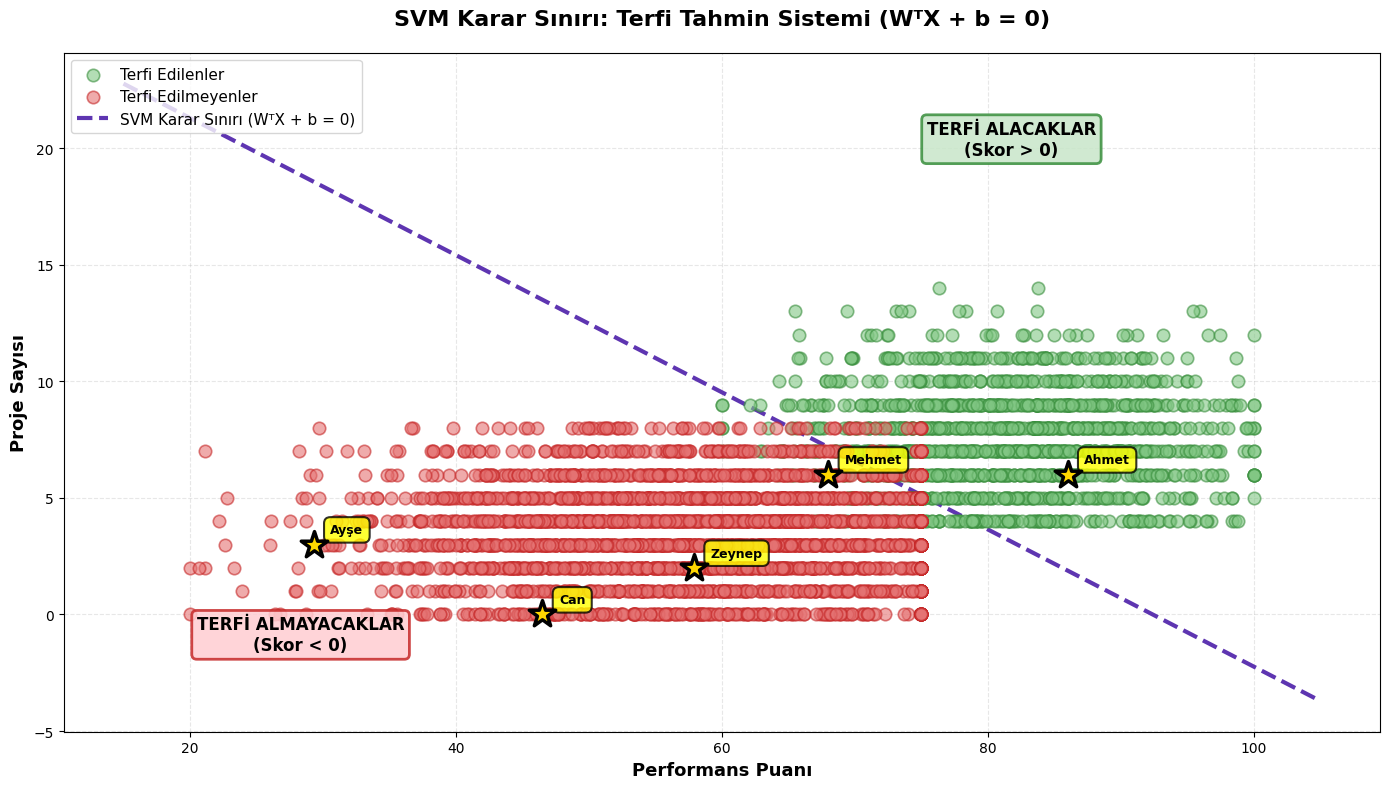


📊 GRAFİK İÇERİĞİ:
----------------------------------------------------------------------
🟢 Yeşil noktalar: Terfi alan çalışanlar
🔴 Kırmızı noktalar: Terfi almayan çalışanlar
🟣 Mor kesikli çizgi: SVM karar sınırı (WᵀX + b = 0)
⭐ Sarı yıldızlar: Örnek çalışanlarımız

💡 Model Doğruluğu: %95.28
   Bu, modelin eğitim verisindeki başarı oranıdır.
   SVM bu çizgiyi marjini maksimize ederek buldu!


In [10]:
# SVM karar sınırını çizelim
plt.figure(figsize=(14, 8))

# Çalışanları çizelim
terfi_mask = df['Terfi_Durumu'] == 1
plt.scatter(df[terfi_mask]['Performans_Puani'], df[terfi_mask]['Proje_Sayisi'], 
           c='#81C784', s=80, alpha=0.6, 
           edgecolors='#388E3C', linewidth=1.2,
           label='Terfi Edilenler', zorder=3)

plt.scatter(df[~terfi_mask]['Performans_Puani'], df[~terfi_mask]['Proje_Sayisi'], 
           c='#E57373', s=80, alpha=0.6,
           edgecolors='#C62828', linewidth=1.2,
           label='Terfi Edilmeyenler', zorder=3)

# Karar sınırını çizelim
# Karar sınırı: w1*x1 + w2*x2 + b = 0
# x2 = -(w1*x1 + b) / w2
x1_range = np.linspace(df['Performans_Puani'].min()-5, df['Performans_Puani'].max()+5, 200)
x2_line = -(w1 * x1_range + b_approx) / w2

plt.plot(x1_range, x2_line, 
        color='#5E35B1', linewidth=3, 
        label='SVM Karar Sınırı (WᵀX + b = 0)',
        linestyle='--', zorder=2)

# Örnek çalışanları işaretleyelim
for idx, calisan in ornek_calisanlar.iterrows():
    plt.scatter(calisan['Performans_Puani'], calisan['Proje_Sayisi'], 
               s=400, c='gold', marker='*', 
               edgecolors='black', linewidth=2.5,
               zorder=5)
    plt.annotate(calisan['İsim'].split()[0], 
                xy=(calisan['Performans_Puani'], calisan['Proje_Sayisi']),
                xytext=(12, 8), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8,
                         edgecolor='black', linewidth=1.5))

plt.xlabel('Performans Puanı', fontsize=13, fontweight='bold')
plt.ylabel('Proje Sayısı', fontsize=13, fontweight='bold')
plt.title('SVM Karar Sınırı: Terfi Tahmin Sistemi (WᵀX + b = 0)', 
         fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')

# Bölge açıklamaları
plt.text(0.72, 0.85, 'TERFİ ALACAKLAR\n(Skor > 0)', 
        transform=plt.gca().transAxes,
        fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#C8E6C9', alpha=0.85, 
                 edgecolor='#388E3C', linewidth=2),
        ha='center')

plt.text(0.18, 0.12, 'TERFİ ALMAYACAKLAR\n(Skor < 0)', 
        transform=plt.gca().transAxes,
        fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#FFCDD2', alpha=0.85, 
                 edgecolor='#C62828', linewidth=2),
        ha='center')

plt.tight_layout()
plt.show()

print("\n📊 GRAFİK İÇERİĞİ:")
print("-" * 70)
print("🟢 Yeşil noktalar: Terfi alan çalışanlar")
print("🔴 Kırmızı noktalar: Terfi almayan çalışanlar")
print("🟣 Mor kesikli çizgi: SVM karar sınırı (WᵀX + b = 0)")
print("⭐ Sarı yıldızlar: Örnek çalışanlarımız")
print(f"\n💡 Model Doğruluğu: %{svm_model.score(X_scaled, y_simple)*100:.2f}")
print("   Bu, modelin eğitim verisindeki başarı oranıdır.")
print("   SVM bu çizgiyi marjini maksimize ederek buldu!")

## 🔬 **Bonus: NumPy ile Vektörel Hesaplama (11 Özellik)**

In [12]:
# Vektörel işlemlerle toplu hesaplama (11 özellik ile)
# Bu yöntem çok daha hızlıdır ve profesyonel kodlamadır

# Tüm özellikleri kullan (Terfi_Durumu hariç)
feature_cols = ['Calisma_Suresi', 'Yas', 'Performans_Puani', 'Egitim_Seviyesi',
                'Proje_Sayisi', 'Fazla_Mesai_Saati', 'Egitim_Katilim', 'Takim_Skoru',
                'Musteri_Memnuniyeti', 'Devamsizlik_Gunu', 'Maas']

X_full = df[feature_cols].values
y_full = df['Terfi_Durumu'].values

# Standartlaştırma
scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X_full)

# Tam SVM modeli
svm_full = SVC(kernel='linear', C=1.0, random_state=42)
svm_full.fit(X_full_scaled, y_full)

# Örnek 5 çalışan için tahmin
ornek_indices = [10, 250, 500, 1000, 2000]
ornek_tam = df.iloc[ornek_indices][feature_cols + ['Terfi_Durumu']].copy()
ornek_tam['Calisan_ID'] = [f'ÇLS-{i:04d}' for i in ornek_indices]

# Tahminler
X_ornek_scaled = scaler_full.transform(ornek_tam[feature_cols].values)
tahminler = svm_full.predict(X_ornek_scaled)
skorlar_full = svm_full.decision_function(X_ornek_scaled)

ornek_tam['Model_Skoru'] = skorlar_full
ornek_tam['Model_Tahmini'] = tahminler
ornek_tam['Gercek_Durum'] = ornek_tam['Terfi_Durumu']

print("🚀 TAM MODEL (11 ÖZELLİK) - VEKTÖREL HESAPLAMA")
print("="*70)
print(f"Model Doğruluğu: {svm_full.score(X_full_scaled, y_full)*100:.2f}%")
print(f"Kullanılan Özellikler: {len(feature_cols)} adet")
print("="*70)
print("\n📊 Örnek Çalışan Tahminleri:\n")

# Gösterim için seçili sütunları yazdır
for _, row in ornek_tam.iterrows():
    print(f"👤 {row['Calisan_ID']}")
    print(f"   Performans: {row['Performans_Puani']:.1f} | Proje: {row['Proje_Sayisi']} | Maaş: {row['Maas']:,} TL")
    print(f"   📊 Model Skoru: {row['Model_Skoru']:.3f}")
    tahmin_text = "✅ TERFİ" if row['Model_Tahmini'] == 1 else "❌ TERFİ YOK"
    gercek_text = "✅ TERFİ" if row['Gercek_Durum'] == 1 else "❌ TERFİ YOK" 
    dogru = "✓" if row['Model_Tahmini'] == row['Gercek_Durum'] else "✗"
    print(f"   🎯 Tahmin: {tahmin_text} | Gerçek: {gercek_text} | {dogru}")
    print("-"*70)

print(f"\n💡 NumPy ve Scikit-learn'ın gücü:")
print(f"   • {len(df):,} çalışan tek seferde işlendi!")
print(f"   • 11 özellik aynı anda değerlendirildi")
print(f"   • Vektörel işlemler sayesinde çok hızlı çalışıyor")
print(f"   • Gerçek sistemlerde milyonlarca kayıt işlenebilir")

🚀 TAM MODEL (11 ÖZELLİK) - VEKTÖREL HESAPLAMA
Model Doğruluğu: 100.00%
Kullanılan Özellikler: 11 adet

📊 Örnek Çalışan Tahminleri:

👤 ÇLS-0010
   Performans: 57.4 | Proje: 4 | Maaş: 14,269 TL
   📊 Model Skoru: -6.385
   🎯 Tahmin: ❌ TERFİ YOK | Gerçek: ❌ TERFİ YOK | ✓
----------------------------------------------------------------------
👤 ÇLS-0250
   Performans: 50.1 | Proje: 1 | Maaş: 11,042 TL
   📊 Model Skoru: -2.475
   🎯 Tahmin: ❌ TERFİ YOK | Gerçek: ❌ TERFİ YOK | ✓
----------------------------------------------------------------------
👤 ÇLS-0500
   Performans: 48.1 | Proje: 1 | Maaş: 13,147 TL
   📊 Model Skoru: -7.086
   🎯 Tahmin: ❌ TERFİ YOK | Gerçek: ❌ TERFİ YOK | ✓
----------------------------------------------------------------------
👤 ÇLS-1000
   Performans: 50.1 | Proje: 2 | Maaş: 11,403 TL
   📊 Model Skoru: -6.537
   🎯 Tahmin: ❌ TERFİ YOK | Gerçek: ❌ TERFİ YOK | ✓
----------------------------------------------------------------------
👤 ÇLS-2000
   Performans: 60.6 | Proje: 

# 📏 **Adım 2: Marjin Kavramı ve Görselleştirme**

## 🎯 **Marjin Nedir ve Neden Önemlidir?**

Bir **karar çizgisi** çizmek kolaydır. Ama **en güvenli** karar çizgisini çizmek zordur!

### 🤔 **Senaryo: İki Farklı Karar Çizgisi**

Elimizde terfi edilecek ve edilmeyecek çalışanlarımız var. İkisini de ayıran **birçok farklı çizgi** çizebiliriz:

**Kötü Çizgi:**
- Çalışanlara çok yakın
- Küçük bir veri değişiminde karar değişebilir
- Güvenilmez

**İyi Çizgi (SVM):**
- Her iki gruptan da maksimum uzaklıkta
- Geniş bir "güvenlik boşluğu" bırakır
- Yeni çalışanlar geldiğinde daha tutarlı

### 📐 **Marjin Tanımı**

**Marjin**: Karar sınırı ile en yakın veri noktaları arasındaki **toplam mesafe**dir.

```
Marjin = 2 × (Karar çizgisinden en yakın noktaya uzaklık)
```

### 🎯 **SVM'in Hedefi**

> **Marjini maksimize et!**

SVM'in görevi sadece doğru sınıflandırma değil, **en geniş güvenlik boşluğu ile doğru sınıflandırma** yapmaktır.

### 💼 **İK Perspektifinden Marjin**

Terfi sisteminde geniş marjin şu anlama gelir:

✅ **Net Terfiler**: Yüksek performans, çok proje → Kesinlikle terfi  
✅ **Net Terfi Yok**: Düşük performans, az proje → Kesinlikle terfi yok  
⚠️ **Sınırda Olanlar**: Orta performans → Özel değerlendirme gerekir

## 🎨 **Mermaid Diyagram: Marjin Kavramı**

In [13]:
# Marjin kavramını açıklayan Mermaid diyagramı
mermaid_margin = '''
```mermaid
graph LR
    A[Veri Noktaları] --> B{Karar Sınırı<br/>Seçimi}
    
    B -->|Rastgele| C[Dar Marjin]
    B -->|SVM| D[Geniş Marjin]
    
    C --> E[Riskli Kararlar<br/>Düşük Güven]
    C --> F[Yeni veriye<br/>kötü genelleme]
    
    D --> G[Güvenli Kararlar<br/>Yüksek Güven]
    D --> H[Yeni veriye<br/>iyi genelleme]
    
    I[Support Vectors<br/>Destek Vektörleri] --> D
    
    style A fill:#E3F2FD,stroke:#1976D2,stroke-width:2px,color:#000
    style B fill:#FFF9C4,stroke:#F57F17,stroke-width:3px,color:#000
    style C fill:#FFEBEE,stroke:#D32F2F,stroke-width:2px,color:#000
    style D fill:#E8F5E9,stroke:#388E3C,stroke-width:3px,color:#000
    style E fill:#FFCDD2,stroke:#C62828,stroke-width:2px,color:#000
    style F fill:#FFCDD2,stroke:#C62828,stroke-width:2px,color:#000
    style G fill:#C8E6C9,stroke:#2E7D32,stroke-width:2px,color:#000
    style H fill:#C8E6C9,stroke:#2E7D32,stroke-width:2px,color:#000
    style I fill:#F3E5F5,stroke:#7B1FA2,stroke-width:2px,color:#000
```
'''

display(Markdown(mermaid_margin))


```mermaid
graph LR
    A[Veri Noktaları] --> B{Karar Sınırı<br/>Seçimi}

    B -->|Rastgele| C[Dar Marjin]
    B -->|SVM| D[Geniş Marjin]

    C --> E[Riskli Kararlar<br/>Düşük Güven]
    C --> F[Yeni veriye<br/>kötü genelleme]

    D --> G[Güvenli Kararlar<br/>Yüksek Güven]
    D --> H[Yeni veriye<br/>iyi genelleme]

    I[Support Vectors<br/>Destek Vektörleri] --> D

    style A fill:#E3F2FD,stroke:#1976D2,stroke-width:2px,color:#000
    style B fill:#FFF9C4,stroke:#F57F17,stroke-width:3px,color:#000
    style C fill:#FFEBEE,stroke:#D32F2F,stroke-width:2px,color:#000
    style D fill:#E8F5E9,stroke:#388E3C,stroke-width:3px,color:#000
    style E fill:#FFCDD2,stroke:#C62828,stroke-width:2px,color:#000
    style F fill:#FFCDD2,stroke:#C62828,stroke-width:2px,color:#000
    style G fill:#C8E6C9,stroke:#2E7D32,stroke-width:2px,color:#000
    style H fill:#C8E6C9,stroke:#2E7D32,stroke-width:2px,color:#000
    style I fill:#F3E5F5,stroke:#7B1FA2,stroke-width:2px,color:#000
```


## 👥 **Support Vectors (Destek Vektörleri) Kavramı**

### 🔍 **Support Vector Nedir?**

**Support Vectors** (Destek Vektörleri), karar sınırına **en yakın** olan veri noktalarıdır.

Bu noktalar özeldir çünkü:

1. **Marjini belirlerler**: Karar sınırının konumu bu noktalara göre belirlenir
2. **Kritik noktalardır**: Bu noktalar olmasa karar sınırı değişir
3. **Diğer noktalar önemli değil**: Destek vektörlerinden uzak noktalar silinse de sonuç değişmez

### 💡 **Analoji: Şirket Terfi Sistemi**

**Support Vectors = Sınırdaki Çalışanlar**

🟢 **Terfi Alan Support Vector:**
- Performans: 72 (orta-iyi)
- Proje: 6 (orta)
- **Durumu:** Terfi aldı ama sınırdaydı

🔴 **Terfi Almayan Support Vector:**
- Performans: 68 (orta)
- Proje: 5 (orta-az)
- **Durumu:** Terfi alamadı ama neredeyse alacaktı

Bu iki çalışan **marjini belirler**. Diğer çalışanlar (çok iyi veya çok kötü performans) karar sınırını etkilemez!

## 📈 **Python ile Marjin ve Support Vectors Görselleştirmesi**

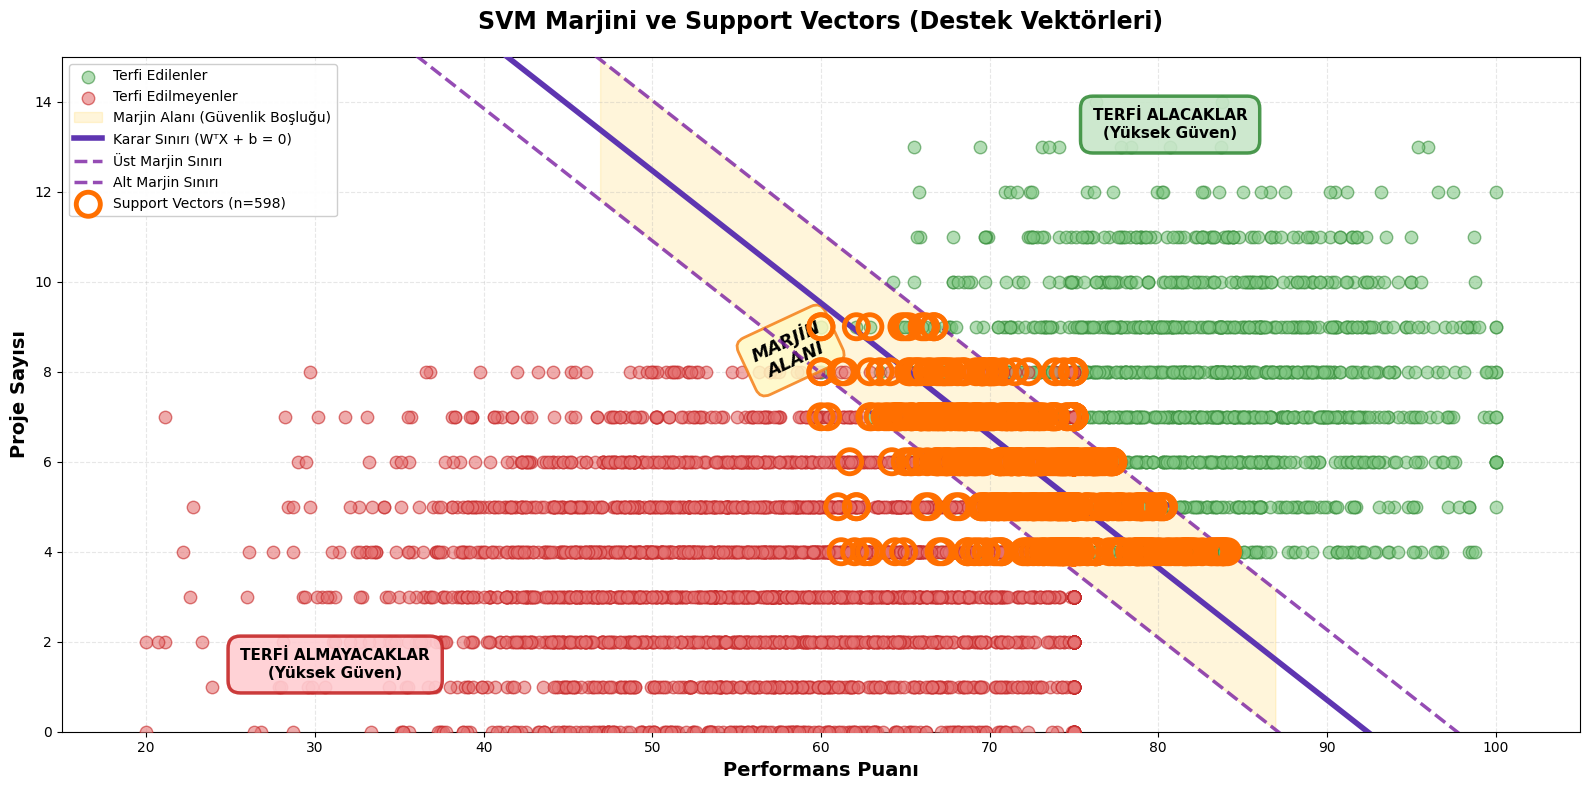

📊 GRAFİK AÇIKLAMASI:
🟣 MOR KALIN ÇİZGİ: Ana karar sınırı (WᵀX + b = 0)
🟣 MOR KESİKLİ ÇİZGİLER: Marjin sınırları (WᵀX + b = ±1)
🟡 SARI ALAN: Marjin (güvenlik boşluğu) - Ne kadar geniş o kadar iyi!
🟠 TURUNCU HALKALAR: Support Vectors - Marjini belirleyen kritik çalışanlar
   → Toplam 598 support vector var
   → Bunlar karar sınırına en yakın çalışanlar
   → Diğer 4,125 çalışan karar sınırını etkilemiyor!

💡 ÖNEMLİ:
   • Marjin ne kadar geniş ise model o kadar güvenilir
   • Support vectors silinse model değişir
   • Diğer noktalar silinse model aynı kalır


In [14]:
# SVM marjin ve support vectors'ü görselleştirelim

plt.figure(figsize=(16, 8))

# Çalışanları çizelim
plt.scatter(df[df['Terfi_Durumu']==1]['Performans_Puani'], 
           df[df['Terfi_Durumu']==1]['Proje_Sayisi'], 
           c='#81C784', s=80, alpha=0.6, 
           edgecolors='#388E3C', linewidth=1,
           label='Terfi Edilenler', zorder=3)

plt.scatter(df[df['Terfi_Durumu']==0]['Performans_Puani'], 
           df[df['Terfi_Durumu']==0]['Proje_Sayisi'], 
           c='#E57373', s=80, alpha=0.6,
           edgecolors='#C62828', linewidth=1,
           label='Terfi Edilmeyenler', zorder=3)

# Karar sınırı ve marjin çizgilerini hesapla
x1_min, x1_max = df['Performans_Puani'].min() - 5, df['Performans_Puani'].max() + 5
x1_range = np.linspace(x1_min, x1_max, 300)

# Ana karar sınırı: w1*x1 + w2*x2 + b = 0
x2_decision = -(w1 * x1_range + b_approx) / w2

# Marjin sınırları: w1*x1 + w2*x2 + b = ±1
# Üst marjin (terfi tarafı)
x2_margin_up = -(w1 * x1_range + b_approx - 1) / w2
# Alt marjin (terfi yok tarafı)  
x2_margin_down = -(w1 * x1_range + b_approx + 1) / w2

# Marjin alanını doldur (şeffaf sarı)
plt.fill_between(x1_range, x2_margin_down, x2_margin_up,
                 where=(x2_margin_down >= 0) & (x2_margin_up <= 15),
                 alpha=0.15, color='#FFC107', 
                 label='Marjin Alanı (Güvenlik Boşluğu)', zorder=1)

# Karar sınırı (kalın mor çizgi)
plt.plot(x1_range, x2_decision, 
        color='#5E35B1', linewidth=4, 
        label='Karar Sınırı (WᵀX + b = 0)',
        linestyle='-', zorder=4)

# Marjin çizgileri (kesikli çizgiler)
plt.plot(x1_range, x2_margin_up, 
        color='#7B1FA2', linewidth=2.5, 
        linestyle='--', alpha=0.8,
        label='Üst Marjin Sınırı', zorder=4)
plt.plot(x1_range, x2_margin_down, 
        color='#7B1FA2', linewidth=2.5, 
        linestyle='--', alpha=0.8,
        label='Alt Marjin Sınırı', zorder=4)

# Support vectors'ü bul ve işaretle
support_vectors = svm_model.support_vectors_
support_vectors_original = scaler.inverse_transform(support_vectors)

plt.scatter(support_vectors_original[:, 0], support_vectors_original[:, 1],
           s=300, facecolors='none', edgecolors='#FF6F00', 
           linewidth=3.5, marker='o',
           label=f'Support Vectors (n={len(support_vectors)})',
           zorder=5)

plt.xlabel('Performans Puanı', fontsize=14, fontweight='bold')
plt.ylabel('Proje Sayısı', fontsize=14, fontweight='bold')
plt.title('SVM Marjini ve Support Vectors (Destek Vektörleri)', 
         fontsize=17, fontweight='bold', pad=20)
plt.legend(fontsize=10, loc='upper left', framealpha=0.95)
plt.grid(True, alpha=0.3, linestyle='--')
plt.ylim(0, 15)
plt.xlim(x1_min, x1_max)

# Açıklama kutuları
plt.text(0.73, 0.88, 'TERFİ ALACAKLAR\n(Yüksek Güven)', 
        transform=plt.gca().transAxes,
        fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#C8E6C9', 
                 alpha=0.9, edgecolor='#388E3C', linewidth=2.5),
        ha='center')

plt.text(0.18, 0.08, 'TERFİ ALMAYACAKLAR\n(Yüksek Güven)', 
        transform=plt.gca().transAxes,
        fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='#FFCDD2', 
                 alpha=0.9, edgecolor='#C62828', linewidth=2.5),
        ha='center')

plt.text(0.48, 0.52, 'MARJİN\nALANI', 
        transform=plt.gca().transAxes,
        fontsize=13, fontweight='bold', style='italic',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='#FFF9C4', 
                 alpha=0.85, edgecolor='#F57F17', linewidth=2),
        ha='center', rotation=25)

plt.tight_layout()
plt.show()

print("📊 GRAFİK AÇIKLAMASI:")
print("="*70)
print(f"🟣 MOR KALIN ÇİZGİ: Ana karar sınırı (WᵀX + b = 0)")
print(f"🟣 MOR KESİKLİ ÇİZGİLER: Marjin sınırları (WᵀX + b = ±1)")
print(f"🟡 SARI ALAN: Marjin (güvenlik boşluğu) - Ne kadar geniş o kadar iyi!")
print(f"🟠 TURUNCU HALKALAR: Support Vectors - Marjini belirleyen kritik çalışanlar")
print(f"   → Toplam {len(support_vectors)} support vector var")
print(f"   → Bunlar karar sınırına en yakın çalışanlar")
print(f"   → Diğer {len(df) - len(support_vectors):,} çalışan karar sınırını etkilemiyor!")
print("\n💡 ÖNEMLİ:")
print("   • Marjin ne kadar geniş ise model o kadar güvenilir")
print("   • Support vectors silinse model değişir")
print("   • Diğer noktalar silinse model aynı kalır")

## 🎯 **Support Vectors'leri Detaylı İnceleyelim**

In [15]:
# Support vectors'leri gerçek veri ile eşleştirelim

# Support vectors'ün orijinal indekslerini bul
support_indices = svm_model.support_

# Bu indekslere karşılık gelen gerçek çalışanları getir
support_calisanlar = df.iloc[support_indices][['Performans_Puani', 'Proje_Sayisi', 
                                                'Calisma_Suresi', 'Maas', 
                                                'Terfi_Durumu']].copy()

# Sınıflarına göre ayır
terfi_sv = support_calisanlar[support_calisanlar['Terfi_Durumu'] == 1]
noterfi_sv = support_calisanlar[support_calisanlar['Terfi_Durumu'] == 0]

print("🎯 SUPPORT VECTORS (DESTEK VEKTÖRLERİ) ANALİZİ")
print("="*70)
print(f"\n📊 Toplam Support Vector Sayısı: {len(support_calisanlar)}")
print(f"   • Terfi Eden Support Vectors: {len(terfi_sv)} kişi")
print(f"   • Terfi Etmeyen Support Vectors: {len(noterfi_sv)} kişi")
print(f"   • Tüm verinin sadece %{len(support_calisanlar)/len(df)*100:.2f}'si kritik!")
print("\n" + "="*70)

print("\n🟢 TERFİ ALAN SUPPORT VECTORS (Sınırdaki Başarılılar):")
print("-"*70)
print(terfi_sv.head(5).to_string(index=False))
print(f"\n📈 Ortalama Performans: {terfi_sv['Performans_Puani'].mean():.1f}")
print(f"📁 Ortalama Proje: {terfi_sv['Proje_Sayisi'].mean():.1f}")

print("\n🔴 TERFİ ALMAYAN SUPPORT VECTORS (Sınırdaki Reddedilenler):")
print("-"*70)
print(noterfi_sv.head(5).to_string(index=False))
print(f"\n📉 Ortalama Performans: {noterfi_sv['Performans_Puani'].mean():.1f}")
print(f"📁 Ortalama Proje: {noterfi_sv['Proje_Sayisi'].mean():.1f}")

print("\n\n💡 SONUÇ:")
print("="*70)
print("✅ Support vectors karar sınırına EN YAKIN çalışanlardır")
print("✅ Bunlar 'sınırdaki' durumlar - net değil, tartışmalı")
print("✅ SVM bu kritik noktaları kullanarak marjini maksimize eder")
print("✅ Diğer çalışanlar (net terfi veya net red) modeli etkilemez")
print("\n🔑 İK İÇİN ÖNEMLİ:")
print("   → Bu çalışanlar özel değerlendirme gerektiren durumlardır")
print("   → Performansları birbirine çok yakın ama sonuçları farklı")
print("   → Model bu hassas ayrımı marjin ile yönetir")

🎯 SUPPORT VECTORS (DESTEK VEKTÖRLERİ) ANALİZİ

📊 Toplam Support Vector Sayısı: 598
   • Terfi Eden Support Vectors: 300 kişi
   • Terfi Etmeyen Support Vectors: 298 kişi
   • Tüm verinin sadece %12.66'si kritik!


🟢 TERFİ ALAN SUPPORT VECTORS (Sınırdaki Başarılılar):
----------------------------------------------------------------------
 Performans_Puani  Proje_Sayisi  Calisma_Suresi  Maas  Terfi_Durumu
             70.1             8             9.2 17758             1
             74.3             6             7.9 19669             1
             75.1             4             4.9 10000             1
             73.9             7             6.0 18831             1
             66.2             5             3.6 20425             1

📈 Ortalama Performans: 72.8
📁 Ortalama Proje: 5.6

🔴 TERFİ ALMAYAN SUPPORT VECTORS (Sınırdaki Reddedilenler):
----------------------------------------------------------------------
 Performans_Puani  Proje_Sayisi  Calisma_Suresi  Maas  Terfi_Durumu
   

## 🏢 **YBS Uygulaması: Marjin ve İş Kararları**

### 📊 **Marjin Genişliğinin İş Anlamı**

| Marjin Durumu | İş Anlamı | Örnek |
|---------------|-----------|-------|
| **Geniş Marjin** | Net ayrım var, güvenli kararlar | Performans 90 vs 45 - Açık fark |
| **Dar Marjin** | Belirsiz ayrım, dikkatli olunmalı | Performans 72 vs 68 - Tartışmalı |
| **Çok Dar Marjin** | Overfitting riski, gürültüye hassas | Model aşırı hassaslaşmış |

### ✨ **SVM'in İK Sistemi için Avantajları**

1. **Adaletli Değerlendirme**: Marjin sayesinde net kriterlere |
2. **Özel Durumları Tanır**: Support vectors özel inceleme gerektirir
3. **Objektif Karar**: Matematiksel temelli, önyargısız
4. **Yeni Çalışanlara Genelleme**: Geniş marjin → İyi tahmin

### 🎯 **Gerçek Dünya Senaryosu**

**Senaryo:** Şirket 100 kişiyi terfi ettirecek. İK müdürü SVM kullanıyor.

**Sonuçlar:**
- ✅ **80 kişi:** Net terfi (marjinin dışında, yüksek performans)
- ✅ **15 kişi:** Net red (marjinin dışında, düşük performans)
- ⚠️ **5 kişi (Support Vectors):** Sınırda → **Yönetici görüşmesi gerekli!**

Bu 5 kişi için **ek kriterlere** bakılır:
- Liderlik potansiyeli
- Takım üzerindeki etki
- Stratejik önemi

**SVM sisteme ne kattı?**
→ Karar sürecini %95 otomatikleştirdi  
→ Sadece kritik 5 kişi manuel değerlendirmeye kaldı  
→ Zaman tasarrufu + Objektif süreç

# ⚖️ **Adım 3: Hard Margin vs Soft Margin**

## 🌍 **Gerçek Dünya Karmaşıktır!**

### 🎯 **İdeal Dünya vs Gerçek Dünya**

**İdeal Dünyada:**
- Tüm veriler mükemmel ayrılır
- Hiç hata yok
- Net sınırlar çizilebilir

**Gerçek Dünyada (İK Sistemi):**
- Yüksek performanslı ama terfi almayan çalışan olabilir (şirket bütçesi sınırlı)
- Düşük performanslı ama terfi alan çalışan olabilir (stratejik pozisyon)
- Veriler iç içe geçmiş olabilir (overlapping)
- Ölçüm hataları var
- İstisnai durumlar var

### ❓ **Peki SVM Ne Yapmalı?**

İşte burada **Hard Margin** ve **Soft Margin** kavramları devreye girer!

## 🔷 **Hard Margin SVM**

### 📋 **Tanım**

**Hard Margin**: Hiçbir veri noktasının yanlış tarafta kalmasına veya marjin içine girmesine izin vermez.

### ✅ **Avantajlar**

- **Matematiksel olarak net**: Kesin çözüm
- **En geniş marjin**: Maksimum ayrım
- **Hiç hata yok**: Tüm veriler doğru sınıflandırılır

### ❌ **Dezavantajlar**

- **Sadece lineer ayrılabilir veride çalışır**: Gerçekte çok nadir
- **Outlier'lara aşırı hassas**: Tek bir aykırı değer tüm modeli bozar
- **Overfitting riski**: Eğitim verisine çok uyar, yeni veriye genelleyemez
- **Gerçekçi değil**: İş dünyasında %100 doğruluk imkansız

### 🏢 **İK Örneği (Hard Margin)**

**Kural:** Her çalışan kesinlikle doğru sınıflandırılmalı!

**Problem:**
- Performansı 85 olan ama terfi almayan 1 kişi var (bütçe kısıtı)
- Model bu 1 kişi yüzünden tüm sistemi değiştirmek zorunda
- Sonuç: Mantıksız karar sınırı

## 🔶 **Soft Margin SVM**

### 📋 **Tanım**

**Soft Margin**: Bazı veri noktalarının yanlış tarafta kalmasına veya marjin içine girmesine **kontrollü şekilde** izin verir.

### ✅ **Avantajlar**

- **Gerçekçidir**: İş dünyası gerçekleriyle uyumlu
- **Outlier'lara dayanıklı**: Aykırı değerler modeli bozmaz
- **Daha iyi genelleme**: Yeni veriye daha iyi çalışır
- **Esnektir**: Mükemmellik yerine denge arar

### 🎚️ **Nasıl Çalışır?**

Soft Margin bir **ceza sistemi** kullanır:

1. **Doğru sınıflandırma**: Ceza yok ✅
2. **Marjin içinde ama doğru taraf**: Küçük ceza ⚠️
3. **Yanlış tarafta**: Büyük ceza ❌

**Hedef**: Marjini maksimize et + Cezaları minimize et

## 🎨 **Mermaid: Hard vs Soft Margin Karşılaştırması**

In [21]:
# Hard Margin vs Soft Margin karşılaştırma diyagramı
mermaid_hardsoft = '''
```mermaid
graph TB
    A[SVM Margin Türleri] --> B[Hard Margin]
    A --> C[Soft Margin]
    
    B --> D[Hiç hata<br/>kabul etmez]
    B --> E[Sadece lineer<br/>ayrılabilir veri]
    B --> F[Outlier'lara<br/>çok hassas]
    B --> G[Overfitting<br/>riski yüksek]
    
    C --> H[Kontrollü<br/>hata kabul eder]
    C --> I[Gerçek dünya<br/>verileriyle çalışır]
    C --> J[Outlier'lara<br/>dayanıklı]
    C --> K[Daha iyi<br/>genelleme]
    
    C --> L[C Parametresi]
    L --> M[C küçük:<br/>Daha toleranslı]
    L --> N[C büyük:<br/>Daha katı]
    
    style A fill:#E3F2FD,stroke:#1976D2,stroke-width:3px,color:#000
    style B fill:#FFEBEE,stroke:#D32F2F,stroke-width:2px,color:#000
    style C fill:#E8F5E9,stroke:#388E3C,stroke-width:2px,color:#000
    style D fill:#FFCDD2,stroke:#C62828,stroke-width:1px,color:#000
    style E fill:#FFCDD2,stroke:#C62828,stroke-width:1px,color:#000
    style F fill:#FFCDD2,stroke:#C62828,stroke-width:1px,color:#000
    style G fill:#FFCDD2,stroke:#C62828,stroke-width:1px,color:#000
    style H fill:#C8E6C9,stroke:#2E7D32,stroke-width:1px,color:#000
    style I fill:#C8E6C9,stroke:#2E7D32,stroke-width:1px,color:#000
    style J fill:#C8E6C9,stroke:#2E7D32,stroke-width:1px,color:#000
    style K fill:#C8E6C9,stroke:#2E7D32,stroke-width:1px,color:#000
    style L fill:#FFF9C4,stroke:#F57F17,stroke-width:2px,color:#000
    style M fill:#FFE082,stroke:#FF8F00,stroke-width:1px,color:#000
    style N fill:#FFE082,stroke:#FF8F00,stroke-width:1px,color:#000
```
'''

display(Markdown(mermaid_hardsoft))


```mermaid
graph TB
    A[SVM Margin Türleri] --> B[Hard Margin]
    A --> C[Soft Margin]

    B --> D[Hiç hata<br/>kabul etmez]
    B --> E[Sadece lineer<br/>ayrılabilir veri]
    B --> F[Outlier'lara<br/>çok hassas]
    B --> G[Overfitting<br/>riski yüksek]

    C --> H[Kontrollü<br/>hata kabul eder]
    C --> I[Gerçek dünya<br/>verileriyle çalışır]
    C --> J[Outlier'lara<br/>dayanıklı]
    C --> K[Daha iyi<br/>genelleme]

    C --> L[C Parametresi]
    L --> M[C küçük:<br/>Daha toleranslı]
    L --> N[C büyük:<br/>Daha katı]

    style A fill:#E3F2FD,stroke:#1976D2,stroke-width:3px,color:#000
    style B fill:#FFEBEE,stroke:#D32F2F,stroke-width:2px,color:#000
    style C fill:#E8F5E9,stroke:#388E3C,stroke-width:2px,color:#000
    style D fill:#FFCDD2,stroke:#C62828,stroke-width:1px,color:#000
    style E fill:#FFCDD2,stroke:#C62828,stroke-width:1px,color:#000
    style F fill:#FFCDD2,stroke:#C62828,stroke-width:1px,color:#000
    style G fill:#FFCDD2,stroke:#C62828,stroke-width:1px,color:#000
    style H fill:#C8E6C9,stroke:#2E7D32,stroke-width:1px,color:#000
    style I fill:#C8E6C9,stroke:#2E7D32,stroke-width:1px,color:#000
    style J fill:#C8E6C9,stroke:#2E7D32,stroke-width:1px,color:#000
    style K fill:#C8E6C9,stroke:#2E7D32,stroke-width:1px,color:#000
    style L fill:#FFF9C4,stroke:#F57F17,stroke-width:2px,color:#000
    style M fill:#FFE082,stroke:#FF8F00,stroke-width:1px,color:#000
    style N fill:#FFE082,stroke:#FF8F00,stroke-width:1px,color:#000
```


## 🎚️ **C Parametresi: Tolerans Ayarı**

### 🔍 **C Parametresi Nedir?**

**C** parametresi, **hata yapma toleransını** kontrol eder. 

```
C = Ceza Katsayısı (Regularization Parameter)
```

### 📊 **C Değerlerinin Etkisi**

| C Değeri | Anlamı | Model Davranışı | İK Karşılığı |
|----------|--------|-----------------|--------------|
| **C → ∞** (çok büyük) | Hard Margin'e yakın | Hata kabul etmez, overfitting riski | Hiç hata yapamayan katı sistem |
| **C = 10** | Orta-katı | Az hata kabul eder | Standart değerlendirme |
| **C = 1** | Dengeli | Makul hata kabul eder | Gerçekçi değerlendirme |
| **C = 0.1** | Esnek | Çok hata kabul eder | Çok toleranslı sistem |
| **C → 0** (çok küçük) | Çok esnek | Neredeyse tüm hatalar OK, underfitting | Hiç diskriminasyon yok |

### ⚖️ **Denge Kurma**

**Yüksek C (Katı):**
- ✅ Eğitim verisinde çok iyi
- ❌ Yeni veriye kötü genelleme
- ❌ Overfitting

**Düşük C (Esnek):**
- ✅ Yeni veriye iyi genelleme
- ❌ Eğitim verisinde zayıf
- ❌ Underfitting

**Optimal C:**
- ✅ Hem eğitimde hem testte iyi
- ✅ Bias-Variance dengesi

### 💼 **İK Perspektifi**

**C = 100 (Katı Sistem):**
> "Her çalışan kesinlikle doğru değerlendirilmeli! Hiç hata yok!"
- Sonuç: Sistem çok karmaşık, yeni çalışanlara uygulanamaz

**C = 1 (Dengeli Sistem):**
> "Genel olarak doğru değerlendirme yapalım, bazı istisnalar olabilir"
- Sonuç: Adil, uygulanabilir, genelleştirilebilir

**C = 0.01 (Çok Esnek):**
> "Herkes geçebilir, çok önemli değil"
- Sonuç: Performans kriterleri anlamsız hale gelir

## 📏 **Slack Variable (ξ) - Hata Payı**

### 🔍 **Slack Variable Nedir?**

**ξ (xi, ksi)**: Her veri noktası için "ne kadar hata yaptığını" ölçen değişken.

```
ξᵢ = 0     → Doğru tarafta ve marjin dışında (mükemmel) ✅
ξᵢ < 1     → Doğru tarafta ama marjin içinde (kabul edilebilir) ⚠️
ξᵢ ≥ 1     → Yanlış tarafta (hata) ❌
```

### 📊 **Görsel Açıklama**

```
               ξ=0        ξ=0.3       ξ=0.8       ξ=1.2
    RED     |    🔴    |  [🔴]  | MARJİN |  [🔴]   🟢    |    YEŞİL
          
    ξ=0: Marjin dışında, doğru tarafta (Mükemmel!)
    ξ=0.3: Marjin içinde, doğru tarafta (İyi)
    ξ=0.8: Karar çizgisine çok yakın (Kritik)
    ξ=1.2: Yanlış tarafta (Hata!)
```

### 🧮 **Matematiksel İfade**

SVM'in optimize ettiği formül:

```
Minimize: (1/2)||W||² + C × Σξᵢ
          ─────────   ─────────
          Marjini      Hataları
          maksimize    minimize
```

**İki hedef aynı anda:**
1. **||W||² küçük** → Geniş marjin
2. **Σξᵢ küçük** → Az hata

**C parametresi** bu ikisinin dengesini kurar!

### 💼 **İK Örneği**

**3 Çalışan Durumu:**

**Ahmet:**
- Performans: 88, Proje: 9
- Terfi aldı, marjin dışında
- **ξ = 0** (mükemmel)
- Ceza: 0

**Ayşe:**
- Performans: 74, Proje: 6
- Terfi aldı ama marjin içinde (sınırda)
- **ξ = 0.4** (kabul edilebilir)
- Ceza: C × 0.4

**Mehmet:**
- Performans: 82, Proje: 8
- Terfi ALMADı ama yüksek performans (bütçe kısıtı)
- **ξ = 1.3** (yanlış sınıflandırma)
- Ceza: C × 1.3 (BÜYÜK CEZA!)

**Toplam Maliyet:**
```
Maliyet = Marjin maliyeti + C × (0 + 0.4 + 1.3)
        = Marjin maliyeti + C × 1.7
```

Model bu maliyeti minimize etmeye çalışır!

## 💻 **Python ile C Parametresi Karşılaştırması**

In [22]:
# Farklı C değerlerinde SVM modelleri eğitelim ve karşılaştıralım

# C değerleri listesi
c_values = [0.01, 0.1, 1, 10, 100]
models = {}
scores = {}
n_support_vectors = {}

print("🔧 FARKLI C DEĞERLERİYLE MODEL EĞİTİMİ")
print("="*70)

# Her C değeri için model eğit
for c in c_values:
    # Model oluştur ve eğit
    svm_temp = SVC(kernel='linear', C=c, random_state=42)
    svm_temp.fit(X_scaled, y_simple)
    
    # Sonuçları kaydet
    models[c] = svm_temp
    scores[c] = svm_temp.score(X_scaled, y_simple)
    n_support_vectors[c] = len(svm_temp.support_vectors_)
    
    print(f"C = {c:6.2f} → Doğruluk: %{scores[c]*100:5.2f} | Support Vectors: {n_support_vectors[c]:3d}")

print("="*70)
print("\n💡 GÖZLEMLER:")
print(f"   • En düşük C ({c_values[0]}): {n_support_vectors[c_values[0]]} support vector")
print(f"   • En yüksek C ({c_values[-1]}): {n_support_vectors[c_values[-1]]} support vector")
print(f"   • C arttıkça support vector sayısı genelde azalır")
print(f"   • Çünkü model daha katı hale gelir, sadece kritik noktalar kalır")

🔧 FARKLI C DEĞERLERİYLE MODEL EĞİTİMİ
C =   0.01 → Doğruluk: %95.00 | Support Vectors: 1008
C =   0.10 → Doğruluk: %95.47 | Support Vectors: 672
C =   1.00 → Doğruluk: %95.28 | Support Vectors: 598
C =  10.00 → Doğruluk: %95.30 | Support Vectors: 585
C = 100.00 → Doğruluk: %95.30 | Support Vectors: 585

💡 GÖZLEMLER:
   • En düşük C (0.01): 1008 support vector
   • En yüksek C (100): 585 support vector
   • C arttıkça support vector sayısı genelde azalır
   • Çünkü model daha katı hale gelir, sadece kritik noktalar kalır


## 📊 **C Parametresi Etkisini Görselleştirelim**

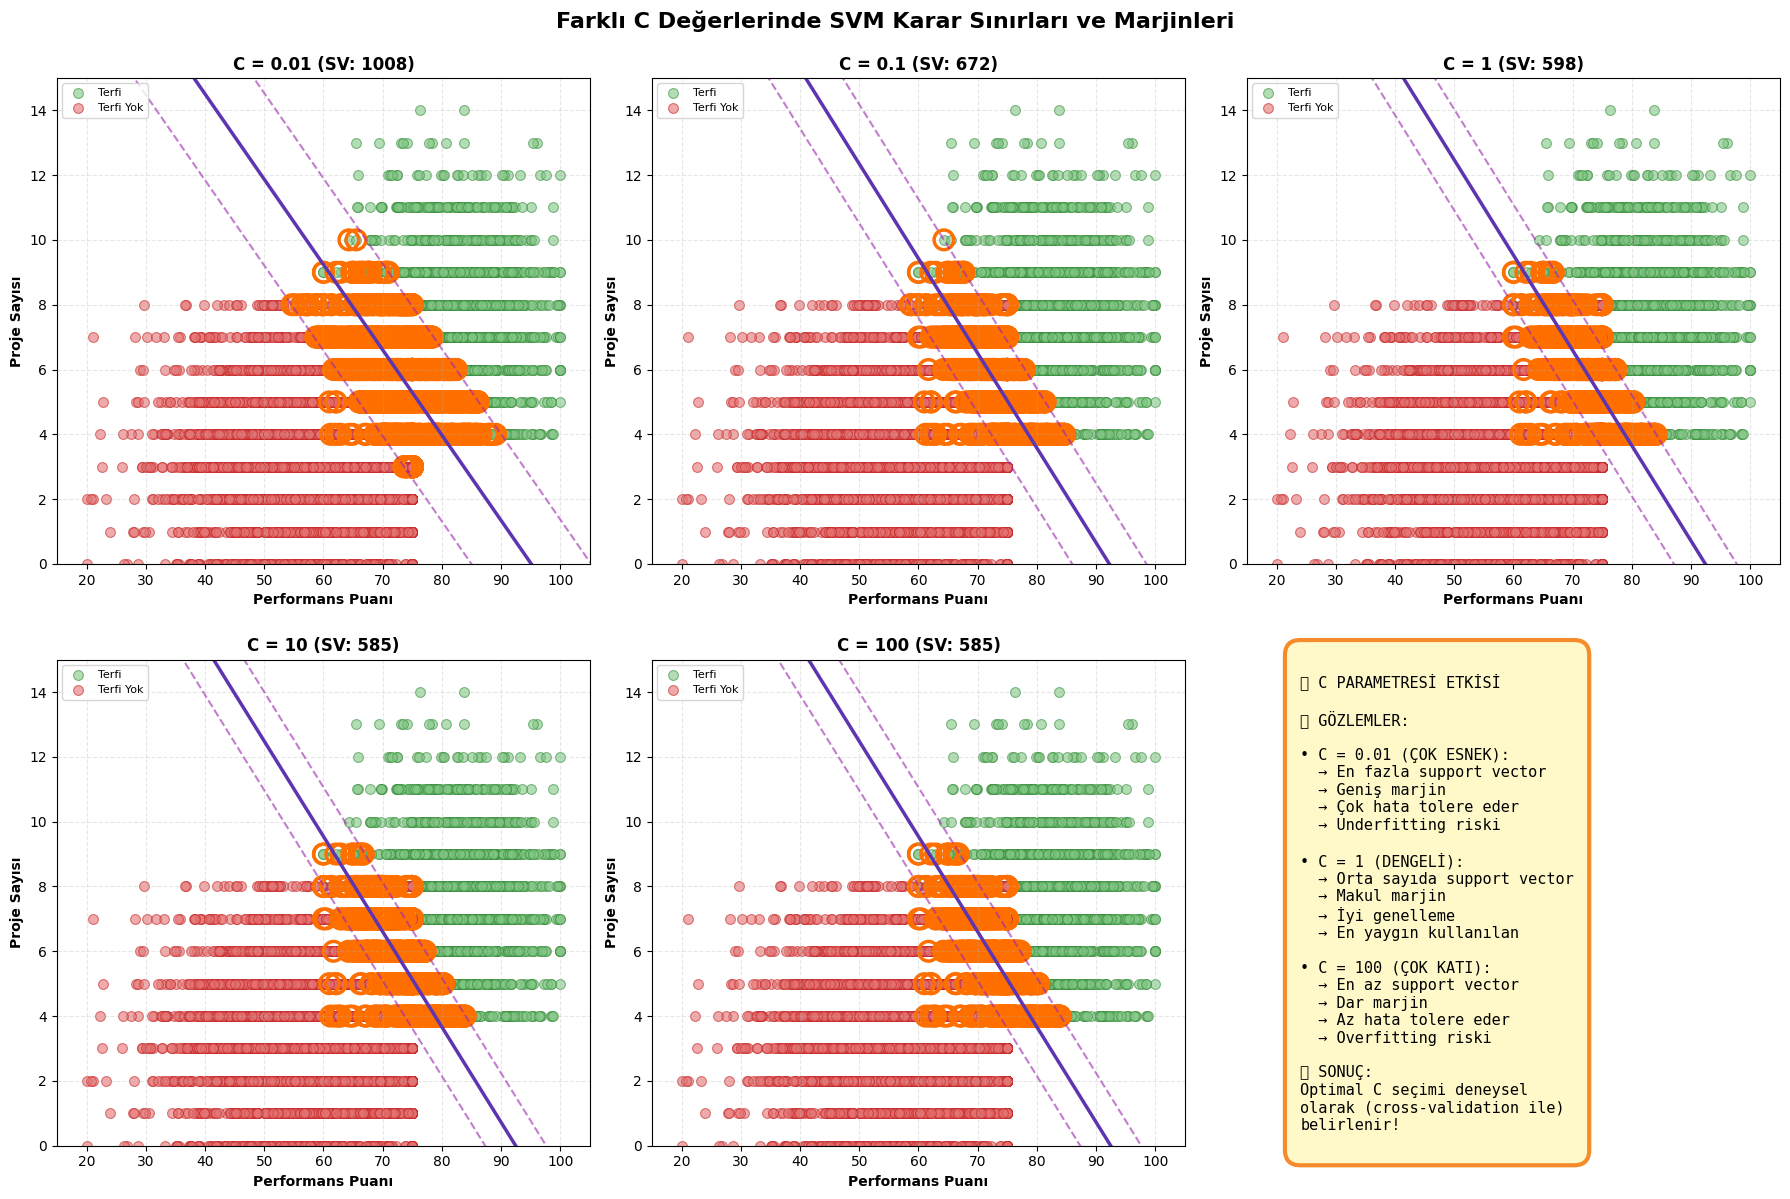


📊 GRAFİK AÇIKLAMASI:
🟣 MOR ÇİZGİ: Karar sınırı (ana çizgi)
🟣 MOR KESİKLİ: Marjin sınırları
🟠 TURUNCU HALKA: Support vectors

💡 DİKKAT EDİN:
   • C küçüldükçe marjin genişler
   • C küçüldükçe support vector sayısı artar
   • C büyüdükçe model daha 'katı' hale gelir
   • Optimal C değeri veri setine bağlıdır


In [23]:
# Farklı C değerlerinde karar sınırlarını görselleştirelim

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# Her C değeri için görselleştirme
for idx, c in enumerate([0.01, 0.1, 1, 10, 100]):
    ax = axes[idx]
    
    # Modeli al
    model = models[c]
    
    # Veri noktalarını çiz
    ax.scatter(df[df['Terfi_Durumu']==1]['Performans_Puani'], 
              df[df['Terfi_Durumu']==1]['Proje_Sayisi'],
              c='#81C784', s=50, alpha=0.6, edgecolors='#388E3C', linewidth=0.8,
              label='Terfi')
    
    ax.scatter(df[df['Terfi_Durumu']==0]['Performans_Puani'], 
              df[df['Terfi_Durumu']==0]['Proje_Sayisi'],
              c='#E57373', s=50, alpha=0.6, edgecolors='#C62828', linewidth=0.8,
              label='Terfi Yok')
    
    # Karar sınırını hesapla
    w1_temp = model.coef_[0][0] / scaler.scale_[0]
    w2_temp = model.coef_[0][1] / scaler.scale_[1]
    b_temp = model.intercept_[0] - (w1_temp * scaler.mean_[0] + w2_temp * scaler.mean_[1])
    
    x1_plot = np.linspace(df['Performans_Puani'].min()-5, df['Performans_Puani'].max()+5, 200)
    x2_plot = -(w1_temp * x1_plot + b_temp) / w2_temp
    
    # Karar sınırını çiz
    ax.plot(x1_plot, x2_plot, color='#5E35B1', linewidth=2.5, linestyle='-')
    
    # Marjin sınırlarını çiz
    x2_margin_up_plot = -(w1_temp * x1_plot + b_temp - 1) / w2_temp
    x2_margin_down_plot = -(w1_temp * x1_plot + b_temp + 1) / w2_temp
    ax.plot(x1_plot, x2_margin_up_plot, color='#9C27B0', linewidth=1.5, linestyle='--', alpha=0.6)
    ax.plot(x1_plot, x2_margin_down_plot, color='#9C27B0', linewidth=1.5, linestyle='--', alpha=0.6)
    
    # Support vectors'ü işaretle
    sv = model.support_vectors_
    sv_original = scaler.inverse_transform(sv)
    ax.scatter(sv_original[:, 0], sv_original[:, 1],
              s=200, facecolors='none', edgecolors='#FF6F00', linewidth=2.5, marker='o')
    
    ax.set_xlabel('Performans Puanı', fontsize=10, fontweight='bold')
    ax.set_ylabel('Proje Sayısı', fontsize=10, fontweight='bold')
    ax.set_title(f'C = {c} (SV: {len(sv)})', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 15)
    ax.set_xlim(df['Performans_Puani'].min()-5, df['Performans_Puani'].max()+5)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=8, loc='upper left')

# 6. paneli bilgi kutusu olarak kullan
ax = axes[5]
ax.axis('off')
info_text = '''
🎯 C PARAMETRESİ ETKİSİ

📊 GÖZLEMLER:

• C = 0.01 (ÇOK ESNEK):
  → En fazla support vector
  → Geniş marjin
  → Çok hata tolere eder
  → Underfitting riski

• C = 1 (DENGELİ):
  → Orta sayıda support vector
  → Makul marjin
  → İyi genelleme
  → En yaygın kullanılan

• C = 100 (ÇOK KATI):
  → En az support vector
  → Dar marjin
  → Az hata tolere eder
  → Overfitting riski

💡 SONUÇ:
Optimal C seçimi deneysel
olarak (cross-validation ile)
belirlenir!
'''

ax.text(0.1, 0.5, info_text, fontsize=11, 
       bbox=dict(boxstyle='round,pad=1', facecolor='#FFF9C4', 
                alpha=0.9, edgecolor='#F57F17', linewidth=3),
       verticalalignment='center', family='monospace')

plt.suptitle('Farklı C Değerlerinde SVM Karar Sınırları ve Marjinleri', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n📊 GRAFİK AÇIKLAMASI:")
print("="*70)
print("🟣 MOR ÇİZGİ: Karar sınırı (ana çizgi)")
print("🟣 MOR KESİKLİ: Marjin sınırları")
print("🟠 TURUNCU HALKA: Support vectors")
print("\n💡 DİKKAT EDİN:")
print("   • C küçüldükçe marjin genişler")
print("   • C küçüldükçe support vector sayısı artar")
print("   • C büyüdükçe model daha 'katı' hale gelir")
print("   • Optimal C değeri veri setine bağlıdır")

## 🎯 **Slack Variables'ı Analiz Edelim**

In [24]:
# Slack variables'ları hesaplayalım (yaklaşık olarak)
# C=1 modelini kullanalım

# Decision function ile her noktanın karar sınırına uzaklığını hesapla
decision_values = svm_model.decision_function(X_scaled)

# Slack hesaplama: ξ = max(0, 1 - yᵢ × (WᵀXᵢ + b))
# Eğer doğru sınıflandırılmış ve marjin dışında: ξ = 0
# Eğer marjin içinde veya yanlış tarafta: ξ > 0

y_signed = 2 * y_simple - 1  # 0,1'den -1,+1'e çevir
slack_values = np.maximum(0, 1 - y_signed * decision_values)

# Slack kategorileri
perfect = slack_values == 0  # Mükemmel
inside_margin = (slack_values > 0) & (slack_values < 1)  # Marjin içinde
misclassified = slack_values >= 1  # Yanlış sınıflandırılmış

print("📊 SLACK VARIABLE ANALİZİ (C=1 modeli)")
print("="*70)
print(f"Toplam Çalışan: {len(df)}")
print(f"\n✅ Mükemmel (ξ=0): {perfect.sum():,} kişi (%{perfect.sum()/len(df)*100:.1f})")
print(f"   → Marjin dışında, doğru tarafta")
print(f"   → Hiç ceza yok")

print(f"\n⚠️ Marjin İçinde (0 < ξ < 1): {inside_margin.sum():,} kişi (%{inside_margin.sum()/len(df)*100:.1f})")
print(f"   → Doğru sınıflandırılmış ama marjin içinde")
print(f"   → Küçük ceza var")
print(f"   → Ortalama ξ: {slack_values[inside_margin].mean():.3f}")

print(f"\n❌ Yanlış Sınıflandırılmış (ξ ≥ 1): {misclassified.sum():,} kişi (%{misclassified.sum()/len(df)*100:.1f})")
print(f"   → Yanlış tarafta")
print(f"   → BÜYÜK ceza var")
print(f"   → Ortalama ξ: {slack_values[misclassified].mean():.3f}")

print(f"\n💰 TOPLAM CEZA (Σξ): {slack_values.sum():.2f}")
print(f"   → Model bu cezayı minimize etmeye çalışıyor!")

# En yüksek slack'e sahip 5 çalışan
top_slack_indices = np.argsort(slack_values)[-5:][::-1]
problematic_calisanlar = df.iloc[top_slack_indices][['Performans_Puani', 'Proje_Sayisi', 
                                                       'Calisma_Suresi', 'Maas', 'Terfi_Durumu']].copy()
problematic_calisanlar['Slack (ξ)'] = slack_values[top_slack_indices]

print("\n\n🚨 EN PROBLEMLI 5 ÇALIŞAN (En yüksek slack):")
print("="*70)
print(problematic_calisanlar.to_string(index=False))

print("\n\n💡 YORUMLAMA:")
print("-"*70)
print("Bu çalışanlar modelin en çok 'zorlandığı' durumlardır.")
print("Performansları beklenenin dışında sonuçlara yol açmıştır.")
print("İş dünyasında bu tür durumlar normaldir:")
print("  • Bütçe kısıtları")
print("  • Stratejik pozisyonlar")
print("  • Özel durumlar")
print("Soft Margin SVM bu durumları KABUL EDER ve sistemi bozmaz!")

📊 SLACK VARIABLE ANALİZİ (C=1 modeli)
Toplam Çalışan: 4723

✅ Mükemmel (ξ=0): 4,128 kişi (%87.4)
   → Marjin dışında, doğru tarafta
   → Hiç ceza yok

⚠️ Marjin İçinde (0 < ξ < 1): 372 kişi (%7.9)
   → Doğru sınıflandırılmış ama marjin içinde
   → Küçük ceza var
   → Ortalama ξ: 0.488

❌ Yanlış Sınıflandırılmış (ξ ≥ 1): 223 kişi (%4.7)
   → Yanlış tarafta
   → BÜYÜK ceza var
   → Ortalama ξ: 1.799

💰 TOPLAM CEZA (Σξ): 582.85
   → Model bu cezayı minimize etmeye çalışıyor!


🚨 EN PROBLEMLI 5 ÇALIŞAN (En yüksek slack):
 Performans_Puani  Proje_Sayisi  Calisma_Suresi  Maas  Terfi_Durumu  Slack (ξ)
             61.2             4             4.6 17247             1   4.320672
             62.0             4             5.6 21565             1   4.169735
             62.6             4             7.6 17447             1   4.056532
             62.9             4             7.2 18013             1   3.999930
             64.4             4             5.8 20039             1   3.716922


💡

## 🏢 **YBS Perspektifi: Gerçek Dünya Uygulaması**

### 📊 **Hard vs Soft Margin Karar Matrisi**

| Durum | Hard Margin Yaklaşımı | Soft Margin Yaklaşımı |
|-------|----------------------|----------------------|
| **Yüksek performanslı ama terfi almayan** | SİSTEM BOZULUR | Slack ile yönetilir |
| **Düşük performanslı ama terfi alan** | SİSTEM BOZULUR | Slack ile yönetilir |
| **Bütçe kısıtları** | Dikkate alınamaz | Esnek karar alabiliyor |
| **Stratejik pozisyonlar** | Model çöker | Outlier olarak tolere edilir |
| **Ölçüm hataları** | Tüm sistemi etkiler | Küçük hatalar absorbe edilir |

### ✨ **Soft Margin'in İK Sistemi İçin Değeri**

1. **Gerçekçiliktir**: %100 doğruluk beklemez
2. **Esnekliktir**: İstisnai durumları kabul eder
3. **Dayanıklılıktır**: Aykırı değerlere karşı robust
4. **Dengedir**: Objektiflik ile esneklik arasında denge

### 🎯 **Pratik Uygulama Önerisi**

**Adım 1:** C = 1 ile başla (genelde iyi çalışır)

**Adım 2:** Cross-validation ile optimal C değerini bul
```python
# C değerlerini dene
C_range = [0.01, 0.1, 1, 10, 100]
# En iyi performansı veren C'yi seç
```

**Adım 3:** Test verisiyle doğrula

**Adım 4:** İş kurallarına göre fine-tune et
- Çok hataya tahammül var mı? → Düşük C
- Kesin kararlar mı gerekiyor? → Yüksek C

### 🔑 **Önemli Not**

> **"Perfect is the enemy of good."**

Hard Margin mükemmel arar ama gerçek dünyada çalışmaz.  
Soft Margin iyi bir denge arar ve **gerçek dünyada çalışır!**

# 📈 **Adım 4: Support Vector Regression (SVR)**

## 🔄 **Sınıflandırmadan Regresyona Geçiş**

### 🎯 **Hatırlatma**

**Şimdiye kadar:**
- **Classification (Sınıflandırma)** → Kategorik tahmin
  - Terfi alır mı? (Evet/Hayır)
  - Müşteri churn yapar mı? (Evet/Hayır)
  - Email spam mi? (Evet/Hayır)

**Şimdi:**
- **Regression (Regresyon)** → Sayısal tahmin
  - Maaş ne kadar olmalı? (Sayısal değer)
  - Satış ne kadar olacak? (Sayısal değer)
  - Ev fiyatı ne olur? (Sayısal değer)

## 🤔 **SVR Nedir?**

**Support Vector Regression (SVR):** SVM'in regresyon problemlerine uygulanmış halidir.

### 🔍 **Temel Fark**

| SVM (Sınıflandırma) | SVR (Regresyon) |
|---------------------|-----------------|
| **Hedef:** İki sınıfı ayıran çizgi | **Hedef:** Verilere uyan çizgi/eğri |
| **Marjin:** Sınıflar arası mesafe | **Epsilon Tube:** Hata tolerans bandı |
| **Karar:** w^T x + b = 0 | **Tahmin:** f(x) = w^T x + + b |
| **Başarı:** Doğru sınıflandırma | **Başarı:** Düşük tahmin hatası |

### 🎯 **SVR'ın Mantığı**

> **"Hataları ε (epsilon) kadar tolere et, bunun dışındakileri cezalandır!"**

**Normal Regresyon:**
- Her hata önemlidir
- En küçük kare hataları minimize et

**SVR:**
- ε kadar hata OK, ceza yok! ✅
- ε'dan büyük hatalar cezalandırılır ❌
- Robust (aykırı değerlere dayanıklı)


## 🎨 **Mermaid: Epsilon Tube Kavramı**

In [31]:
# Epsilon Tube kavramı diyagramı
mermaid_epsilon = '''
```mermaid
graph TB
    A[SVR: Support Vector Regression] --> B[Epsilon Tube ε]
    
    B --> C[Tahmin Çizgisi<br/>f x = wx + b]
    B --> D[Üst Sınır<br/>f x + ε]
    B --> E[Alt Sınır<br/>f x - ε]
    
    C --> F[Veri Noktaları]
    
    F --> G[Tube İçinde<br/>Hata ≤ ε]
    F --> H[Tube Dışında<br/>Hata > ε]
    
    G --> I[Ceza YOK<br/>ξ = 0]
    H --> J[CEZA VAR<br/>ξ > 0]
    
    I --> K[Bu noktalar<br/>modeli etkilemez]
    J --> L[Bu noktalar<br/>Support Vectors]
    
    style A fill:#E3F2FD,stroke:#1976D2,stroke-width:3px,color:#000
    style B fill:#FFF9C4,stroke:#F57F17,stroke-width:3px,color:#000
    style C fill:#C8E6C9,stroke:#2E7D32,stroke-width:2px,color:#000
    style D fill:#FFE082,stroke:#FF8F00,stroke-width:1px,color:#000
    style E fill:#FFE082,stroke:#FF8F00,stroke-width:1px,color:#000
    style F fill:#E1BEE7,stroke:#6A1B9A,stroke-width:2px,color:#000
    style G fill:#C8E6C9,stroke:#2E7D32,stroke-width:2px,color:#000
    style H fill:#FFCDD2,stroke:#C62828,stroke-width:2px,color:#000
    style I fill:#A5D6A7,stroke:#1B5E20,stroke-width:1px,color:#000
    style J fill:#EF9A9A,stroke:#B71C1C,stroke-width:1px,color:#000
    style K fill:#E8F5E9,stroke:#388E3C,stroke-width:1px,color:#000
    style L fill:#FFEBEE,stroke:#D32F2F,stroke-width:1px,color:#000
```
'''

display(Markdown(mermaid_epsilon))


```mermaid
graph TB
    A[SVR: Support Vector Regression] --> B[Epsilon Tube ε]

    B --> C[Tahmin Çizgisi<br/>f x = wx + b]
    B --> D[Üst Sınır<br/>f x + ε]
    B --> E[Alt Sınır<br/>f x - ε]

    C --> F[Veri Noktaları]

    F --> G[Tube İçinde<br/>Hata ≤ ε]
    F --> H[Tube Dışında<br/>Hata > ε]

    G --> I[Ceza YOK<br/>ξ = 0]
    H --> J[CEZA VAR<br/>ξ > 0]

    I --> K[Bu noktalar<br/>modeli etkilemez]
    J --> L[Bu noktalar<br/>Support Vectors]

    style A fill:#E3F2FD,stroke:#1976D2,stroke-width:3px,color:#000
    style B fill:#FFF9C4,stroke:#F57F17,stroke-width:3px,color:#000
    style C fill:#C8E6C9,stroke:#2E7D32,stroke-width:2px,color:#000
    style D fill:#FFE082,stroke:#FF8F00,stroke-width:1px,color:#000
    style E fill:#FFE082,stroke:#FF8F00,stroke-width:1px,color:#000
    style F fill:#E1BEE7,stroke:#6A1B9A,stroke-width:2px,color:#000
    style G fill:#C8E6C9,stroke:#2E7D32,stroke-width:2px,color:#000
    style H fill:#FFCDD2,stroke:#C62828,stroke-width:2px,color:#000
    style I fill:#A5D6A7,stroke:#1B5E20,stroke-width:1px,color:#000
    style J fill:#EF9A9A,stroke:#B71C1C,stroke-width:1px,color:#000
    style K fill:#E8F5E9,stroke:#388E3C,stroke-width:1px,color:#000
    style L fill:#FFEBEE,stroke:#D32F2F,stroke-width:1px,color:#000
```


## 💻 **Python ile SVR: Maaş Tahmini Örneği**

In [32]:
# SVR için gerekli kütüphaneyi import et
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Mevcut verisetimizden yararlanarak maaş tahmin modeli oluşturalım
# X: Performans Puanı (tek özellik, basit örnek)
# y: Maaş (hedef değişken)

# Veriyi hazırla
X_maas = df[['Performans_Puani']].values
y_maas = df['Maas'].values

print("🎯 SVR MAAS TAHMİN MODELİ")
print("="*70)
print(f"Veri Seti: {len(df)} çalışan")
print(f"Özellik: Performans Puanı")
print(f"Hedef: Maaş (TL)")
print(f"\nMaaş İstatistikleri:")
print(f"  • Minimum: {y_maas.min():,.0f} TL")
print(f"  • Maksimum: {y_maas.max():,.0f} TL")
print(f"  • Ortalama: {y_maas.mean():,.0f} TL")
print(f"  • Standart Sapma: {y_maas.std():,.0f} TL")
print("="*70)

🎯 SVR MAAS TAHMİN MODELİ
Veri Seti: 4723 çalışan
Özellik: Performans Puanı
Hedef: Maaş (TL)

Maaş İstatistikleri:
  • Minimum: 5,500 TL
  • Maksimum: 33,110 TL
  • Ortalama: 13,915 TL
  • Standart Sapma: 4,321 TL


## 🔧 **Farklı Epsilon Değerleriyle SVR Modelleri**

In [33]:
# Farklı epsilon değerleriyle SVR modelleri eğitelim
epsilon_values = [500, 1000, 2000, 3000]
svr_models = {}
svr_scores = {}
svr_predictions = {}

print("\n🔧 FARKLI EPSİLON DEĞERLERİYLE SVR EĞİTİMİ")
print("="*70)

for eps in epsilon_values:
    # SVR modeli oluştur (Linear kernel, epsilon değişken)
    svr = SVR(kernel='linear', epsilon=eps, C=1.0)
    
    # Modeli eğit
    svr.fit(X_maas, y_maas)
    
    # Tahmin yap
    y_pred = svr.predict(X_maas)
    
    # Performans metrikleri
    mae = mean_absolute_error(y_maas, y_pred)
    rmse = np.sqrt(mean_squared_error(y_maas, y_pred))
    r2 = r2_score(y_maas, y_pred)
    
    # Kaydet
    svr_models[eps] = svr
    svr_scores[eps] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    svr_predictions[eps] = y_pred
    
    # Support vectors sayısı
    n_sv = len(svr.support_vectors_)
    
    print(f"\nε = {eps:,} TL:")
    print(f"  • MAE (Ortalama Mutlak Hata): {mae:,.0f} TL")
    print(f"  • RMSE (Kök Ortalama Kare Hata): {rmse:,.0f} TL")
    print(f"  • R² Skoru: {r2:.4f}")
    print(f"  • Support Vectors: {n_sv}")

print("="*70)
print("\n💡 YORUMLAMA:")
print("   • Epsilon arttıkça tube genişler")
print("   • Tube genişledikçe support vector sayısı azalır")
print("   • MAE/RMSE ile epsilon arasında trade-off vardır")
print("   • Optimal epsilon veri setine bağlıdır")


🔧 FARKLI EPSİLON DEĞERLERİYLE SVR EĞİTİMİ

ε = 500 TL:
  • MAE (Ortalama Mutlak Hata): 3,021 TL
  • RMSE (Kök Ortalama Kare Hata): 3,807 TL
  • R² Skoru: 0.2239
  • Support Vectors: 4221

ε = 1,000 TL:
  • MAE (Ortalama Mutlak Hata): 3,021 TL
  • RMSE (Kök Ortalama Kare Hata): 3,807 TL
  • R² Skoru: 0.2238
  • Support Vectors: 3711

ε = 2,000 TL:
  • MAE (Ortalama Mutlak Hata): 3,021 TL
  • RMSE (Kök Ortalama Kare Hata): 3,805 TL
  • R² Skoru: 0.2247
  • Support Vectors: 2807

ε = 3,000 TL:
  • MAE (Ortalama Mutlak Hata): 3,022 TL
  • RMSE (Kök Ortalama Kare Hata): 3,802 TL
  • R² Skoru: 0.2258
  • Support Vectors: 2020

💡 YORUMLAMA:
   • Epsilon arttıkça tube genişler
   • Tube genişledikçe support vector sayısı azalır
   • MAE/RMSE ile epsilon arasında trade-off vardır
   • Optimal epsilon veri setine bağlıdır


## 📊 **SVR Görselleştirmesi: Epsilon Tube**

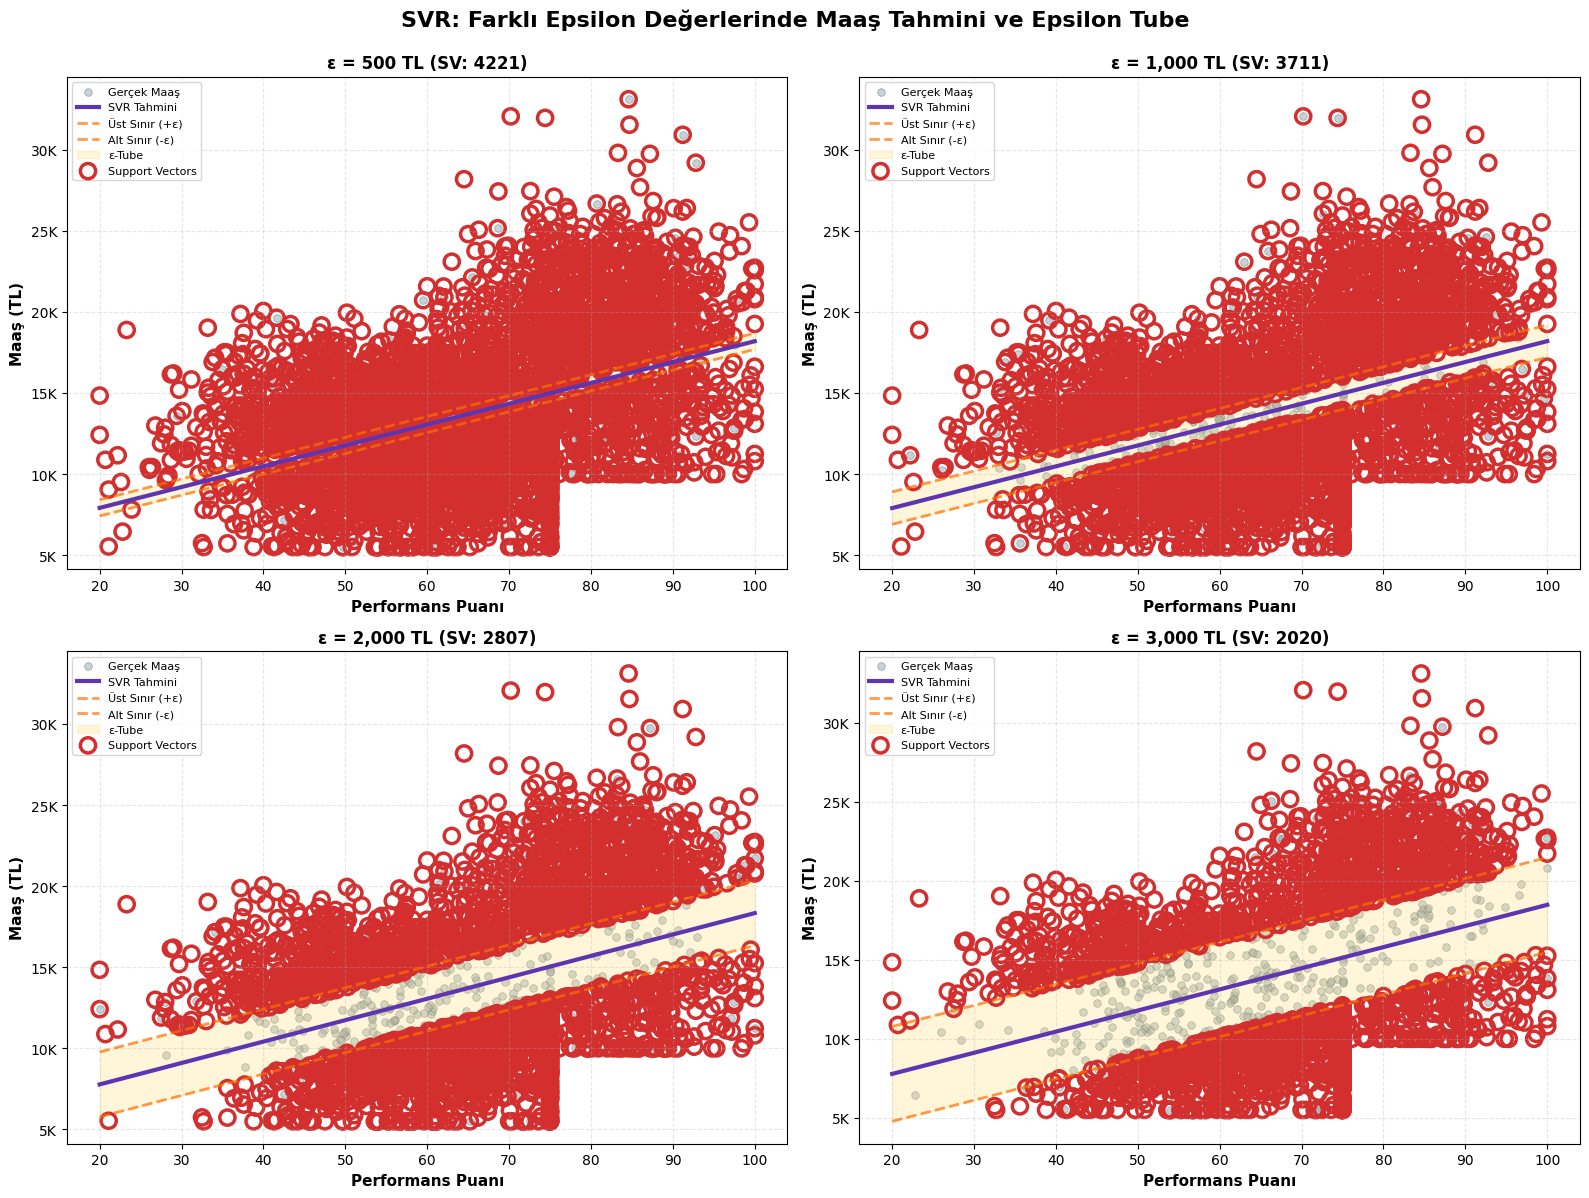


📊 GRAFİK AÇIKLAMASI:
🟣 MOR ÇİZGİ: SVR tahmin çizgisi
🟠 TURUNCU KESİKLİ: Epsilon tube sınırları
🟡 SARI ALAN: ε-Tube (kabul edilebilir hata bölgesi)
🔴 KIRMIZI HALKA: Support vectors (tube dışındaki noktalar)
⚪ GRİ NOKTALAR: Tüm veri noktaları

💡 DİKKAT EDİN:
   • Epsilon arttıkça tube genişler
   • Tube genişledikçe kırmızı halka (SV) sayısı azalır
   • Tube içindeki noktalar modeli etkilemez
   • Sadece tube dışındaki noktalar support vectors'tir


In [34]:
# SVR epsilon tube görselleştirmesi
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for idx, eps in enumerate(epsilon_values):
    ax = axes[idx]
    
    # Modeli al
    svr = svr_models[eps]
    y_pred = svr_predictions[eps]
    
    # Tüm veri noktalarını çiz (sample alarak, çok kalabalık olmasın)
    sample_indices = np.random.choice(len(df), size=500, replace=False)
    X_sample = X_maas[sample_indices]
    y_sample = y_maas[sample_indices]
    
    # Veri noktaları
    ax.scatter(X_sample, y_sample, c='#90A4AE', s=30, alpha=0.5, 
              edgecolors='#455A64', linewidth=0.5, label='Gerçek Maaş')
    
    # Tahmin çizgisi için X değerleri
    X_line = np.linspace(X_maas.min(), X_maas.max(), 100).reshape(-1, 1)
    y_line = svr.predict(X_line)
    
    # Tahmin çizgisi
    ax.plot(X_line, y_line, color='#5E35B1', linewidth=3, label='SVR Tahmini')
    
    # Epsilon tube sınırları
    ax.plot(X_line, y_line + eps, color='#FF6F00', linewidth=2, 
           linestyle='--', alpha=0.7, label=f'Üst Sınır (+ε)')
    ax.plot(X_line, y_line - eps, color='#FF6F00', linewidth=2, 
           linestyle='--', alpha=0.7, label=f'Alt Sınır (-ε)')
    
    # Epsilon tube'u gölgele
    ax.fill_between(X_line.ravel(), y_line - eps, y_line + eps, 
                    color='#FFE082', alpha=0.3, label='ε-Tube')
    
    # Support vectors'ü işaretle
    sv_indices = svr.support_
    ax.scatter(X_maas[sv_indices], y_maas[sv_indices], 
              s=120, facecolors='none', edgecolors='#D32F2F', 
              linewidth=2.5, marker='o', label='Support Vectors')
    
    ax.set_xlabel('Performans Puanı', fontsize=11, fontweight='bold')
    ax.set_ylabel('Maaş (TL)', fontsize=11, fontweight='bold')
    ax.set_title(f'ε = {eps:,} TL (SV: {len(sv_indices)})', 
                fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=8, loc='upper left')
    
    # Y ekseni formatı
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))

plt.suptitle('SVR: Farklı Epsilon Değerlerinde Maaş Tahmini ve Epsilon Tube', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n📊 GRAFİK AÇIKLAMASI:")
print("="*70)
print("🟣 MOR ÇİZGİ: SVR tahmin çizgisi")
print("🟠 TURUNCU KESİKLİ: Epsilon tube sınırları")
print("🟡 SARI ALAN: ε-Tube (kabul edilebilir hata bölgesi)")
print("🔴 KIRMIZI HALKA: Support vectors (tube dışındaki noktalar)")
print("⚪ GRİ NOKTALAR: Tüm veri noktaları")
print("\n💡 DİKKAT EDİN:")
print("   • Epsilon arttıkça tube genişler")
print("   • Tube genişledikçe kırmızı halka (SV) sayısı azalır")
print("   • Tube içindeki noktalar modeli etkilemez")
print("   • Sadece tube dışındaki noktalar support vectors'tir")

## 🎯 **Pratik Örnek: Yeni Çalışan Maaş Tahmini**

In [35]:
# Optimal epsilon ile maaş tahmini yapalım (ε = 1000 TL seçelim)
svr_optimal = svr_models[1000]

# 5 farklı performans seviyesinde çalışan için maaş tahmini
test_performanslar = [50, 60, 70, 80, 90]

print("\n💼 YENİ ÇALIŞAN MAAŞ TAHMİNİ (ε = 1,000 TL)")
print("="*70)

for perf in test_performanslar:
    tahmin_maas = svr_optimal.predict([[perf]])[0]
    
    # Gerçek veriden benzer performansa sahip çalışanların ortalama maaşı
    benzer_calisanlar = df[(df['Performans_Puani'] >= perf-2) & 
                           (df['Performans_Puani'] <= perf+2)]
    
    if len(benzer_calisanlar) > 0:
        gercek_ortalama = benzer_calisanlar['Maas'].mean()
        fark = abs(tahmin_maas - gercek_ortalama)
        
        print(f"\n📊 Performans: {perf}/100")
        print(f"   SVR Tahmini: {tahmin_maas:,.0f} TL")
        print(f"   Gerçek Ortalama: {gercek_ortalama:,.0f} TL")
        print(f"   Fark: {fark:,.0f} TL", end="")
        
        if fark <= 1000:  # epsilon değerimiz
            print(" ✅ (ε-Tube içinde)")
        else:
            print(" ❌ (ε-Tube dışında)")
    else:
        print(f"\n📊 Performans: {perf}/100")
        print(f"   SVR Tahmini: {tahmin_maas:,.0f} TL")
        print(f"   (Bu performans seviyesinde veri az)")

print("\n" + "="*70)
print("💡 SONUÇ:")
print("   SVR, performans puanından maaş tahmin edebiliyor!")
print("   ε = 1,000 TL tolerans ile gerçekçi tahminler yapıyor.")
print("   İK departmanı bu modeli maaş belirleme için kullanabilir.")


💼 YENİ ÇALIŞAN MAAŞ TAHMİNİ (ε = 1,000 TL)

📊 Performans: 50/100
   SVR Tahmini: 11,764 TL
   Gerçek Ortalama: 12,018 TL
   Fark: 254 TL ✅ (ε-Tube içinde)

📊 Performans: 60/100
   SVR Tahmini: 13,050 TL
   Gerçek Ortalama: 12,159 TL
   Fark: 891 TL ✅ (ε-Tube içinde)

📊 Performans: 70/100
   SVR Tahmini: 14,337 TL
   Gerçek Ortalama: 13,627 TL
   Fark: 710 TL ✅ (ε-Tube içinde)

📊 Performans: 80/100
   SVR Tahmini: 15,623 TL
   Gerçek Ortalama: 17,622 TL
   Fark: 1,999 TL ❌ (ε-Tube dışında)

📊 Performans: 90/100
   SVR Tahmini: 16,909 TL
   Gerçek Ortalama: 17,715 TL
   Fark: 806 TL ✅ (ε-Tube içinde)

💡 SONUÇ:
   SVR, performans puanından maaş tahmin edebiliyor!
   ε = 1,000 TL tolerans ile gerçekçi tahminler yapıyor.
   İK departmanı bu modeli maaş belirleme için kullanabilir.


# 🌀 **Adım 5: Kernel Trick (Çekirdek Hilesi)**

## 🤔 **Problem: Lineer Ayrılamayan Veriler**

### 📊 **Şimdiye Kadar Ne Gördük?**

**Adım 1-4'te:**
- Linear SVM (düz çizgi/düzlem)
- Hard/Soft Margin
- SVR (epsilon tube)
- Tümü **lineer** karar sınırları kullandı

**Gerçek Dünya Problemi:**
> Peki ya veriler düz çizgi ile ayrılamıyorsa? 🤷

### 🎯 **Örnek: İç İçe Geçmiş Veri**

```
        YEŞİL ALAN (Terfi Alan)
    🟢 🟢 🟢 🟢 🟢 🟢 🟢
  🟢 🔴 🔴 🔴 🔴 🔴 🔴 🟢
 🟢 🔴           🔴 🟢
🟢 🔴    KIRMIZI   🔴 🟢
🟢 🔴    (Terfi    🔴 🟢
🟢 🔴    Almayan)  🔴 🟢
 🟢 🔴           🔴 🟢
  🟢 🔴 🔴 🔴 🔴 🔴 🔴 🟢
    🟢 🟢 🟢 🟢 🟢 🟢 🟢
```

**Lineer SVM:** Bu veriyi ayıramaz! ❌  
**Kernel Trick:** Bu veriyi ayırabilir! ✅

## 🎩 **Kernel Trick Nedir?**

**Kernel Trick:** Veriyi daha yüksek boyuta taşıyarak, orada lineer ayrılabilir hale getirme tekniği.

### 🧠 **Temel Fikir**

**1. Düşük Boyutta:** Veriler lineer ayrılamaz (2D'de çember)  
**2. Yüksek Boyuta Taşı:** 3D, 4D, hatta ∞ boyut  
**3. Yüksek Boyutta:** Veriler lineer ayrılabilir hale gelir  
**4. Karar Sınırı:** Yüksek boyutta düzlem, alçak boyutta eğri

### 🎨 **Görsel Analoji**

**2D'de (zeminde):**
- Kırmızı toplar ortada, yeşil toplar çevrede
- Düz çizgi ile ayıramazsın ❌

**3D'ye taşı (havaya kaldır):**
- Kırmızı toplar aşağıda, yeşil toplar yukarıda
- Düz düzlem ile ayırabilirsin ✅
- Bu düzlem 2D'ye geri döndüğünde **çember** olur!

### 💡 **Sihir: Hesaplamayı Yapmadan Sonuç**

**Normal Yöntem:**
1. Veriyi yüksek boyuta taşı (çok pahalı!)
2. Orada lineer SVM uygula
3. Geri dön

**Kernel Trick:**
1. Hiç taşıma! 🎩
2. "Sanki taşımış gibi" hesapla (Kernel fonksiyonu)
3. Aynı sonuç, çok daha hızlı!

## 🎨 **Mermaid: Kernel Trick Konsepti**

In [41]:
# Kernel Trick konsept diyagramı
mermaid_kernel = '''
```mermaid
graph LR
    A[Orijinal Veri<br/>2D - Lineer Ayrılamaz] --> B[Kernel Fonksiyonu]
    
    B --> C[Linear Kernel<br/>K x,y = x·y]
    B --> D[Polynomial Kernel<br/>K x,y = x·y + 1 ^d]
    B --> E[RBF Gaussian Kernel<br/>K x,y = exp -γ x-y ²]
    
    C --> F[Düz Çizgi<br/>Basit Problem]
    D --> G[Polinom Eğri<br/>Orta Karmaşıklık]
    E --> H[Esnek Eğri<br/>Yüksek Karmaşıklık]
    
    F --> I[En Hızlı<br/>Sınırlı Esneklik]
    G --> J[Orta Hız<br/>Parametreli degree]
    H --> K[Yavaş<br/>En Esnek]
    
    style A fill:#FFEBEE,stroke:#C62828,stroke-width:3px,color:#000
    style B fill:#E3F2FD,stroke:#1976D2,stroke-width:3px,color:#000
    style C fill:#E8F5E9,stroke:#388E3C,stroke-width:2px,color:#000
    style D fill:#FFF9C4,stroke:#F57F17,stroke-width:2px,color:#000
    style E fill:#F3E5F5,stroke:#6A1B9A,stroke-width:2px,color:#000
    style F fill:#C8E6C9,stroke:#2E7D32,stroke-width:1px,color:#000
    style G fill:#FFE082,stroke:#FF8F00,stroke-width:1px,color:#000
    style H fill:#E1BEE7,stroke:#7B1FA2,stroke-width:1px,color:#000
    style I fill:#A5D6A7,stroke:#1B5E20,stroke-width:1px,color:#000
    style J fill:#FFD54F,stroke:#F57F00,stroke-width:1px,color:#000
    style K fill:#CE93D8,stroke:#4A148C,stroke-width:1px,color:#000
```
'''

display(Markdown(mermaid_kernel))


```mermaid
graph LR
    A[Orijinal Veri<br/>2D - Lineer Ayrılamaz] --> B[Kernel Fonksiyonu]

    B --> C[Linear Kernel<br/>K x,y = x·y]
    B --> D[Polynomial Kernel<br/>K x,y = x·y + 1 ^d]
    B --> E[RBF Gaussian Kernel<br/>K x,y = exp -γ x-y ²]

    C --> F[Düz Çizgi<br/>Basit Problem]
    D --> G[Polinom Eğri<br/>Orta Karmaşıklık]
    E --> H[Esnek Eğri<br/>Yüksek Karmaşıklık]

    F --> I[En Hızlı<br/>Sınırlı Esneklik]
    G --> J[Orta Hız<br/>Parametreli degree]
    H --> K[Yavaş<br/>En Esnek]

    style A fill:#FFEBEE,stroke:#C62828,stroke-width:3px,color:#000
    style B fill:#E3F2FD,stroke:#1976D2,stroke-width:3px,color:#000
    style C fill:#E8F5E9,stroke:#388E3C,stroke-width:2px,color:#000
    style D fill:#FFF9C4,stroke:#F57F17,stroke-width:2px,color:#000
    style E fill:#F3E5F5,stroke:#6A1B9A,stroke-width:2px,color:#000
    style F fill:#C8E6C9,stroke:#2E7D32,stroke-width:1px,color:#000
    style G fill:#FFE082,stroke:#FF8F00,stroke-width:1px,color:#000
    style H fill:#E1BEE7,stroke:#7B1FA2,stroke-width:1px,color:#000
    style I fill:#A5D6A7,stroke:#1B5E20,stroke-width:1px,color:#000
    style J fill:#FFD54F,stroke:#F57F00,stroke-width:1px,color:#000
    style K fill:#CE93D8,stroke:#4A148C,stroke-width:1px,color:#000
```


## 📚 **3 Popüler Kernel Türü**

### 1️⃣ **Linear Kernel (Lineer Çekirdek)**

**Formül:**
```
K(x, y) = x · y
```

**Ne Zaman Kullanılır:**
- Veriler zaten lineer ayrılabilir
- Özellik sayısı çok fazla (high-dimensional)
- Hız öncelikli

**Avantajlar:**
- ✅ Çok hızlı
- ✅ Yorumlanabilir
- ✅ Overfitting riski düşük

**Dezavantajlar:**
- ❌ Sadece lineer ilişkiler

**İK Örneği:**
> Terfi kararı sadece performans puanına bağlı (düz çizgi yeterli)

### 2️⃣ **Polynomial Kernel (Polinom Çekirdek)**

**Formül:**
```
K(x, y) = (x · y + c)^d
```
- **d:** Polinom derecesi (2, 3, 4, ...)
- **c:** Sabit terim (genelde 1)

**Ne Zaman Kullanılır:**
- Orta düzeyde non-linearity
- İlişkiler polinom şeklinde (x², x³, vs.)
- Kontrollü esneklik gerekli

**Avantajlar:**
- ✅ Lineer'den daha esnek
- ✅ Polinom derecesi ile ayarlanabilir
- ✅ Orta hızda

**Dezavantajlar:**
- ❌ Yüksek derecede numerik sorunlar
- ❌ Parametre seçimi kritik

**İK Örneği:**
> Terfi olasılığı performansın karesiyle artar (kuadratik ilişki)

### 3️⃣ **RBF (Radial Basis Function) Kernel - Gaussian**

**Formül:**
```
K(x, y) = exp(-γ ||x - y||²)
```
- **γ (gamma):** Esneklik parametresi
- **||x - y||²:** Noktalar arası Euclidean mesafenin karesi

**Ne Zaman Kullanılır:**
- Çok karmaşık non-linear ilişkiler
- İlişki bilinmiyor, esnek model gerekli
- En yaygın kullanılan kernel

**Avantajlar:**
- ✅ Son derece esnek
- ✅ Karmaşık ilişkileri yakalar
- ✅ Çoğu problemde iyi çalışır

**Dezavantajlar:**
- ❌ Yavaş (büyük verisetlerinde)
- ❌ Overfitting riski yüksek
- ❌ Gamma parametresi kritik

**Gamma (γ) Etkisi:**
- **Küçük γ:** Geniş etki alanı, düzgün sınır (underfitting riski)
- **Büyük γ:** Dar etki alanı, karmaşık sınır (overfitting riski)

**İK Örneği:**
> Terfi kararı birçok faktörün karmaşık etkileşimine bağlı (non-linear)

## 💻 **Python ile Farklı Kernel'ları Karşılaştırma**

In [42]:
# Mevcut verisetimizle farklı kernel'ları deneyelim
from time import time

# Test edilecek kernel'lar
kernels = {
    'linear': {'kernel': 'linear', 'C': 1.0},
    'poly_2': {'kernel': 'poly', 'degree': 2, 'C': 1.0, 'coef0': 1},
    'poly_3': {'kernel': 'poly', 'degree': 3, 'C': 1.0, 'coef0': 1},
    'rbf_01': {'kernel': 'rbf', 'C': 1.0, 'gamma': 0.1},
    'rbf_1': {'kernel': 'rbf', 'C': 1.0, 'gamma': 1.0},
    'rbf_10': {'kernel': 'rbf', 'C': 1.0, 'gamma': 10.0},
}

kernel_results = {}

print("🔧 FARKLI KERNEL'LARLA SVM KARŞILAŞTIRMASI")
print("="*80)
print(f"Veri: {len(df)} çalışan, 2 özellik (Performans Puanı, Proje Sayısı)")
print("="*80)

for name, params in kernels.items():
    # Zamanı başlat
    start_time = time()
    
    # Model oluştur ve eğit
    model = SVC(**params, random_state=42)
    model.fit(X_scaled, y_simple)
    
    # Eğitim süresi
    train_time = time() - start_time
    
    # Performans
    accuracy = model.score(X_scaled, y_simple)
    n_support = len(model.support_vectors_)
    
    # Kaydet
    kernel_results[name] = {
        'model': model,
        'accuracy': accuracy,
        'n_support': n_support,
        'train_time': train_time,
        'params': params
    }
    
    # Yazdır
    kernel_type = params['kernel']
    if kernel_type == 'linear':
        print(f"\n📊 LINEAR:")
    elif kernel_type == 'poly':
        degree = params['degree']
        print(f"\n📊 POLYNOMIAL (derece={degree}):")
    elif kernel_type == 'rbf':
        gamma = params['gamma']
        print(f"\n📊 RBF (gamma={gamma}):")
    
    print(f"   • Doğruluk: %{accuracy*100:.2f}")
    print(f"   • Support Vectors: {n_support}")
    print(f"   • Eğitim Süresi: {train_time:.3f} saniye")

print("\n" + "="*80)
print("\n💡 GENEL DEĞERLENDIRME:")
print("-"*80)

# En iyi doğruluk
best_acc = max(kernel_results.values(), key=lambda x: x['accuracy'])
print(f"✅ En Yüksek Doğruluk: {list(kernel_results.keys())[list(kernel_results.values()).index(best_acc)]} "
      f"(%{best_acc['accuracy']*100:.2f})")

# En hızlı
fastest = min(kernel_results.values(), key=lambda x: x['train_time'])
print(f"⚡ En Hızlı: {list(kernel_results.keys())[list(kernel_results.values()).index(fastest)]} "
      f"({fastest['train_time']:.3f} saniye)")

# En az support vector
min_sv = min(kernel_results.values(), key=lambda x: x['n_support'])
print(f"🎯 En Az Support Vector: {list(kernel_results.keys())[list(kernel_results.values()).index(min_sv)]} "
      f"({min_sv['n_support']} SV)")

print("\n📌 SONUÇ:")
print("   • Linear kernel en hızlıdır")
print("   • RBF kernel en esnektir (çoğu durumda en iyi doğruluk)")
print("   • Polynomial kernel orta yol sunar")
print("   • Gamma arttıkça RBF daha karmaşık hale gelir")

🔧 FARKLI KERNEL'LARLA SVM KARŞILAŞTIRMASI
Veri: 4723 çalışan, 2 özellik (Performans Puanı, Proje Sayısı)

📊 LINEAR:
   • Doğruluk: %95.28
   • Support Vectors: 598
   • Eğitim Süresi: 0.021 saniye

📊 POLYNOMIAL (derece=2):
   • Doğruluk: %95.38
   • Support Vectors: 576
   • Eğitim Süresi: 0.024 saniye

📊 POLYNOMIAL (derece=3):
   • Doğruluk: %95.15
   • Support Vectors: 554
   • Eğitim Süresi: 0.026 saniye

📊 RBF (gamma=0.1):
   • Doğruluk: %95.32
   • Support Vectors: 631
   • Eğitim Süresi: 0.033 saniye

📊 RBF (gamma=1.0):
   • Doğruluk: %95.30
   • Support Vectors: 571
   • Eğitim Süresi: 0.036 saniye

📊 RBF (gamma=10.0):
   • Doğruluk: %95.96
   • Support Vectors: 1061
   • Eğitim Süresi: 0.116 saniye


💡 GENEL DEĞERLENDIRME:
--------------------------------------------------------------------------------
✅ En Yüksek Doğruluk: rbf_10 (%95.96)
⚡ En Hızlı: linear (0.021 saniye)
🎯 En Az Support Vector: poly_3 (554 SV)

📌 SONUÇ:
   • Linear kernel en hızlıdır
   • RBF kernel en esnekt

## 📊 **Kernel Karşılaştırma Görselleştirmesi**

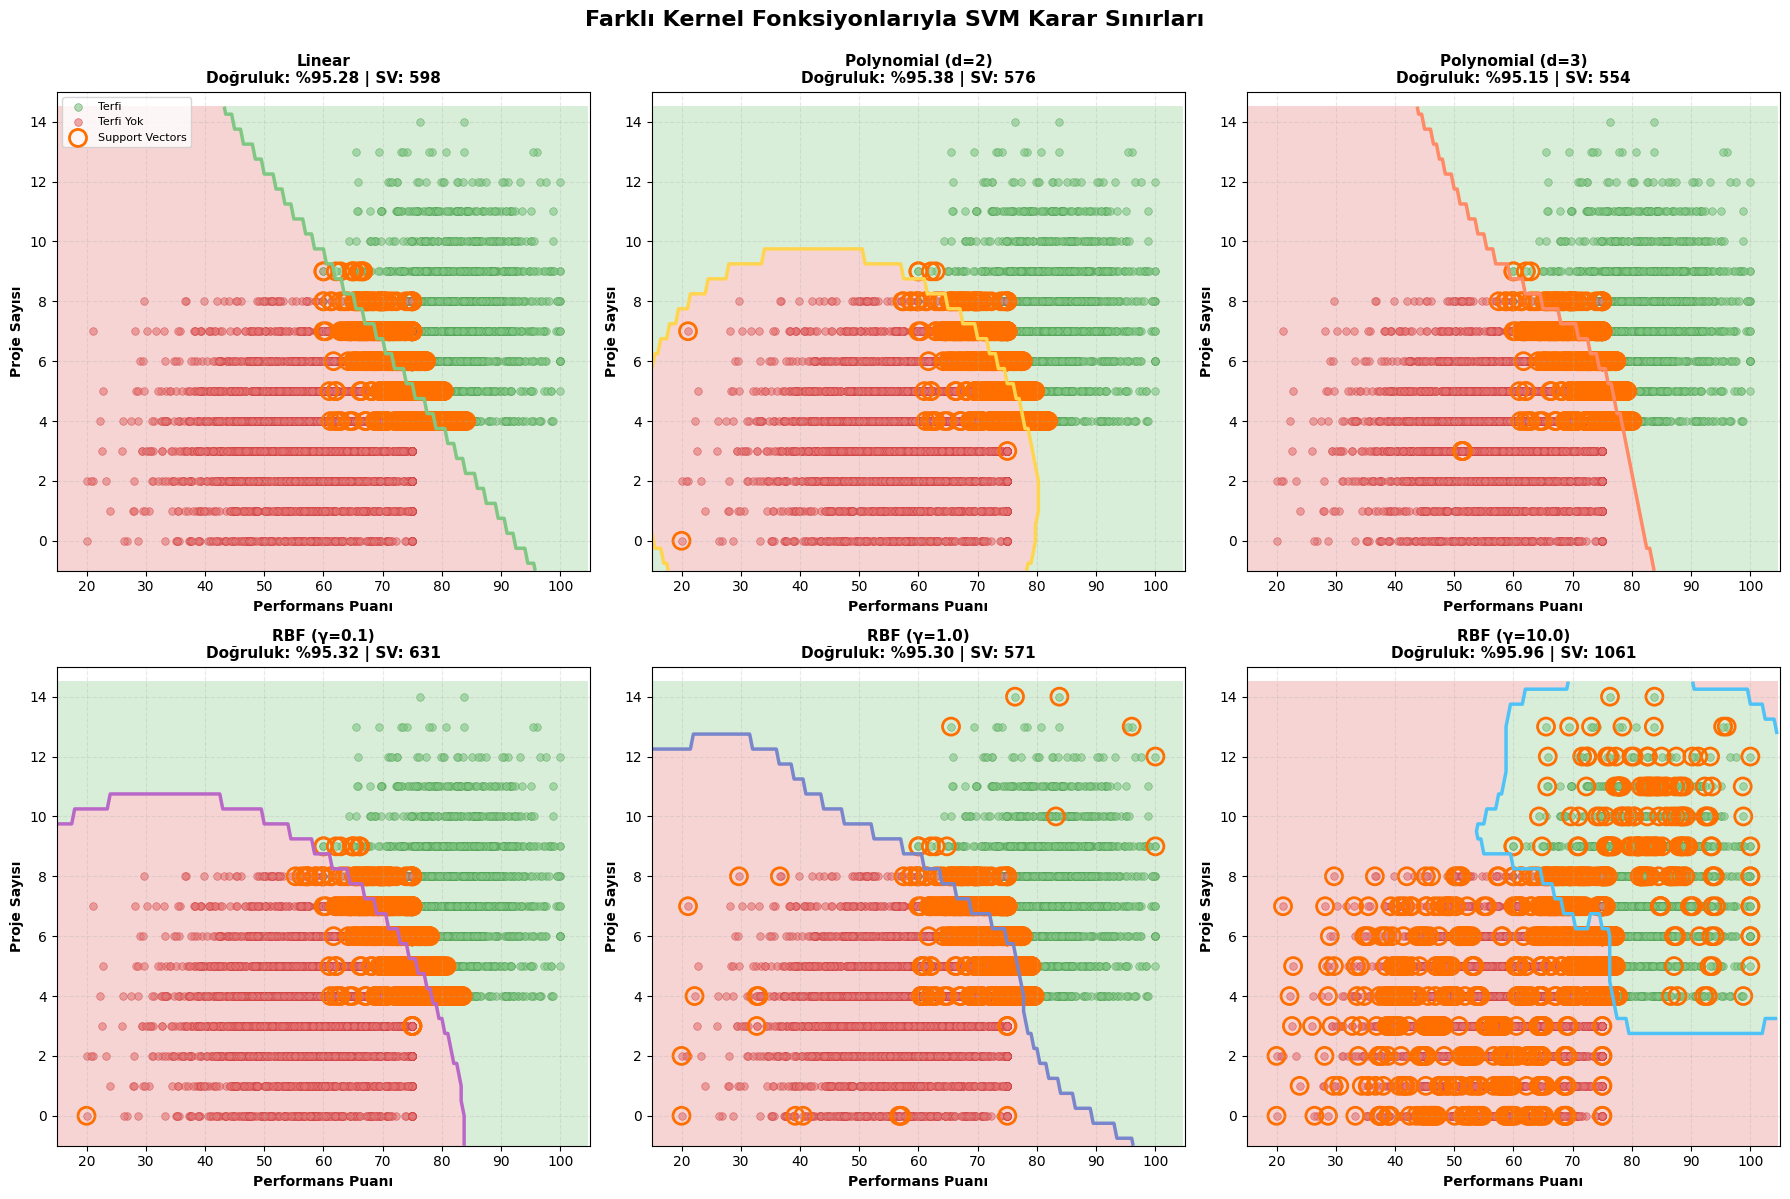


📊 GRAFİK AÇIKLAMASI:
🟢 YEŞİL BÖLGE: Terfi tahmin edilen alan
🔴 KIRMIZI BÖLGE: Terfi yok tahmin edilen alan
🟠 TURUNCU HALKA: Support vectors

💡 DİKKAT EDİN:
   • Linear: Düz çizgi (en basit)
   • Polynomial: Eğrisel sınır (derece arttıkça karmaşıklaşır)
   • RBF: Çok esnek sınır (gamma arttıkça daha karmaşık)
   • RBF (γ=10): Çok karmaşık, overfitting riski var!
   • RBF (γ=0.1): Dengeli, genelleştirilebilir


In [44]:
# Farklı kernel'ların karar sınırlarını görselleştirelim
from matplotlib import colors as mcolors

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

kernel_names = ['linear', 'poly_2', 'poly_3', 'rbf_01', 'rbf_1', 'rbf_10']
kernel_titles = ['Linear', 'Polynomial (d=2)', 'Polynomial (d=3)', 
                 'RBF (γ=0.1)', 'RBF (γ=1.0)', 'RBF (γ=10.0)']
kernel_colors = ['#81C784', '#FFD54F', '#FF8A65', '#BA68C8', '#7986CB', '#4FC3F7']

for idx, (kernel_name, kernel_title, color) in enumerate(zip(kernel_names, kernel_titles, kernel_colors)):
    ax = axes[idx]
    
    # Modeli al
    result = kernel_results[kernel_name]
    model = result['model']
    accuracy = result['accuracy']
    n_support = result['n_support']
    
    # Veri noktalarını çiz
    ax.scatter(df[df['Terfi_Durumu']==1]['Performans_Puani'], 
              df[df['Terfi_Durumu']==1]['Proje_Sayisi'],
              c='#81C784', s=30, alpha=0.6, edgecolors='#388E3C', linewidth=0.5,
              label='Terfi')
    
    ax.scatter(df[df['Terfi_Durumu']==0]['Performans_Puani'], 
              df[df['Terfi_Durumu']==0]['Proje_Sayisi'],
              c='#E57373', s=30, alpha=0.6, edgecolors='#C62828', linewidth=0.5,
              label='Terfi Yok')
    
    # Karar sınırını çizmek için mesh grid oluştur
    h = 0.5  # mesh step size
    x_min, x_max = df['Performans_Puani'].min() - 5, df['Performans_Puani'].max() + 5
    y_min, y_max = df['Proje_Sayisi'].min() - 1, df['Proje_Sayisi'].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    # Her nokta için tahmin yap
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    mesh_points_scaled = scaler.transform(mesh_points)
    Z = model.predict(mesh_points_scaled)
    Z = Z.reshape(xx.shape)
    
    # Karar sınırını çiz
    ax.contourf(xx, yy, Z, alpha=0.3, levels=1, colors=[mcolors.to_rgba('#E57373', 0.3), 
                                                         mcolors.to_rgba('#81C784', 0.3)])
    ax.contour(xx, yy, Z, colors=[color], linewidths=2.5, levels=[0.5])
    
    # Support vectors'ü işaretle
    sv = model.support_vectors_
    sv_original = scaler.inverse_transform(sv)
    ax.scatter(sv_original[:, 0], sv_original[:, 1],
              s=150, facecolors='none', edgecolors='#FF6F00', linewidth=2, marker='o',
              label='Support Vectors')
    
    ax.set_xlabel('Performans Puanı', fontsize=10, fontweight='bold')
    ax.set_ylabel('Proje Sayısı', fontsize=10, fontweight='bold')
    ax.set_title(f'{kernel_title}\nDoğruluk: %{accuracy*100:.2f} | SV: {n_support}', 
                fontsize=11, fontweight='bold')
    ax.set_ylim(y_min, y_max)
    ax.set_xlim(x_min, x_max)
    ax.grid(True, alpha=0.3, linestyle='--')
    if idx == 0:
        ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Farklı Kernel Fonksiyonlarıyla SVM Karar Sınırları', 
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n📊 GRAFİK AÇIKLAMASI:")
print("="*70)
print("🟢 YEŞİL BÖLGE: Terfi tahmin edilen alan")
print("🔴 KIRMIZI BÖLGE: Terfi yok tahmin edilen alan")
print("🟠 TURUNCU HALKA: Support vectors")
print("\n💡 DİKKAT EDİN:")
print("   • Linear: Düz çizgi (en basit)")
print("   • Polynomial: Eğrisel sınır (derece arttıkça karmaşıklaşır)")
print("   • RBF: Çok esnek sınır (gamma arttıkça daha karmaşık)")
print("   • RBF (γ=10): Çok karmaşık, overfitting riski var!")
print("   • RBF (γ=0.1): Dengeli, genelleştirilebilir")

## 🎯 **Kernel Seçim Rehberi**

In [46]:
# Kernel seçim rehberi tablosu
from IPython.display import Markdown

kernel_guide = '''
## 📋 **Kernel Seçim Tablosu**

| Durum | Önerilen Kernel | Neden? |
|-------|-----------------|--------|
| **Veriler lineer ayrılabilir** | Linear | En hızlı, yorumlanabilir |
| **Çok fazla özellik (>1000)** | Linear | Yüksek boyutta genelde lineer yeterli |
| **Küçük veriset** | Linear veya RBF (düşük γ) | Overfitting riski azaltmak için |
| **Büyük veriset (>10K)** | Linear | Hız kritik |
| **Orta büyüklük, karmaşık ilişki** | RBF | En popüler, çoğu durumda iyi |
| **İlişki polinom şeklinde** | Polynomial | x², x³ gibi ilişkiler varsa |
| **Çok karmaşık, bilinmeyen ilişki** | RBF (cross-validation ile γ ayarla) | En esnek |
| **Hız öncelikli** | Linear | O(n) karmaşıklık |
| **Doğruluk öncelikli** | RBF veya Polynomial | Non-linear ilişkileri yakalar |

## ⚙️ **Parametre Ayarlama Önerileri**

### **RBF Kernel için γ (Gamma):**

```python
# Başlangıç değerleri
gamma_range = [0.001, 0.01, 0.1, 1, 10, 100]

# Kural:
# - Küçük γ: Geniş etki alanı, düzgün sınır → Underfitting riski
# - Büyük γ: Dar etki alanı, karmaşık sınır → Overfitting riski
# - Genelde: γ ≈ 1 / (n_features × X.var()) çalışır
```

### **Polynomial Kernel için degree (d):**

```python
# Başlangıç değerleri
degree_range = [2, 3, 4, 5]

# Kural:
# - d=2: Kuadratik ilişkiler (x¹, x², x¹x²)
# - d=3: Kübik ilişkiler (x³, x²y, xy², vs.)
# - d>3: Çok karmaşık, numerik sorunlar!
# - Genelde: d=2 veya d=3 yeterlidir
```

### **Tüm Kernel'lar için C:**

```python
# Başlangıç değerleri
C_range = [0.1, 1, 10, 100]

# Kural:
# - Küçük C: Daha soft margin, genelleme iyi
# - Büyük C: Daha hard margin, eğitimde iyi
# - Genelde: C=1 iyi başlangıç
```

## 🔬 **Cross-Validation ile Optimal Seçim**

```python
from sklearn.model_selection import GridSearchCV

# Parametre grid'i tanımla
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

# Grid search
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

# En iyi parametreler
print(f"En iyi parametreler: {grid.best_params_}")
print(f"En iyi doğruluk: {grid.best_score_:.3f}")
```
'''

display(Markdown(kernel_guide))


## 📋 **Kernel Seçim Tablosu**

| Durum | Önerilen Kernel | Neden? |
|-------|-----------------|--------|
| **Veriler lineer ayrılabilir** | Linear | En hızlı, yorumlanabilir |
| **Çok fazla özellik (>1000)** | Linear | Yüksek boyutta genelde lineer yeterli |
| **Küçük veriset** | Linear veya RBF (düşük γ) | Overfitting riski azaltmak için |
| **Büyük veriset (>10K)** | Linear | Hız kritik |
| **Orta büyüklük, karmaşık ilişki** | RBF | En popüler, çoğu durumda iyi |
| **İlişki polinom şeklinde** | Polynomial | x², x³ gibi ilişkiler varsa |
| **Çok karmaşık, bilinmeyen ilişki** | RBF (cross-validation ile γ ayarla) | En esnek |
| **Hız öncelikli** | Linear | O(n) karmaşıklık |
| **Doğruluk öncelikli** | RBF veya Polynomial | Non-linear ilişkileri yakalar |

## ⚙️ **Parametre Ayarlama Önerileri**

### **RBF Kernel için γ (Gamma):**

```python
# Başlangıç değerleri
gamma_range = [0.001, 0.01, 0.1, 1, 10, 100]

# Kural:
# - Küçük γ: Geniş etki alanı, düzgün sınır → Underfitting riski
# - Büyük γ: Dar etki alanı, karmaşık sınır → Overfitting riski
# - Genelde: γ ≈ 1 / (n_features × X.var()) çalışır
```

### **Polynomial Kernel için degree (d):**

```python
# Başlangıç değerleri
degree_range = [2, 3, 4, 5]

# Kural:
# - d=2: Kuadratik ilişkiler (x¹, x², x¹x²)
# - d=3: Kübik ilişkiler (x³, x²y, xy², vs.)
# - d>3: Çok karmaşık, numerik sorunlar!
# - Genelde: d=2 veya d=3 yeterlidir
```

### **Tüm Kernel'lar için C:**

```python
# Başlangıç değerleri
C_range = [0.1, 1, 10, 100]

# Kural:
# - Küçük C: Daha soft margin, genelleme iyi
# - Büyük C: Daha hard margin, eğitimde iyi
# - Genelde: C=1 iyi başlangıç
```

## 🔬 **Cross-Validation ile Optimal Seçim**

```python
from sklearn.model_selection import GridSearchCV

# Parametre grid'i tanımla
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

# Grid search
grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

# En iyi parametreler
print(f"En iyi parametreler: {grid.best_params_}")
print(f"En iyi doğruluk: {grid.best_score_:.3f}")
```
